# Dynamics

In [2]:
# Dynamic Programming: Iterative Policy Evaluation

states = ["P", "Q", "R", "G"]   # All states; G is the terminal state

gamma = 0.9                     # Discount factor for future rewards
tolerance = 1e-5                # Stop when the largest state-value change is below this


# Initial state-value estimates
state_value = {
    "P": 0.0,                   # Initial guess for V(P)
    "Q": 0.0,                   # Initial guess for V(Q)
    "R": 0.0,                   # Initial guess for V(R)
    "G": 0.0                    # Terminal state value is always 0
}


# Policy: probability of selecting each action in each state
policy = {
    "P": {
        "a1": 0.7,              # pi(a1 | P) = 0.7
        "a2": 0.3               # pi(a2 | P) = 0.3
    },

    "Q": {
        "a1": 1.0               # At Q, a1 is always selected
    },

    "R": {
        "a1": 1.0               # At R, a1 is always selected
    },

    "G": {}                     # No actions from terminal state
}


# Environment model:
# (probability, next_state, reward)
transitions = {

    ("P", "a1"): [
        (0.8, "Q", 2),          # 80% chance: P --a1--> Q, reward +2
        (0.2, "P", -1)          # 20% chance: P --a1--> P, reward -1
    ],

    ("P", "a2"): [
        (1.0, "R", 4)           # 100% chance: P --a2--> R, reward +4
    ],

    ("Q", "a1"): [
        (0.6, "G", 8),          # 60% chance: Q --a1--> G, reward +8
        (0.4, "P", 0)           # 40% chance: Q --a1--> P, reward 0
    ],

    ("R", "a1"): [
        (0.7, "G", 6),          # 70% chance: R --a1--> G, reward +6
        (0.3, "Q", 1)           # 30% chance: R --a1--> Q, reward +1
    ]
}


iteration = 0                   # Number of completed DP iterations


while True:

    iteration += 1              # Start a new iteration

    previous_state_value = state_value.copy()
    # Keep V_k(S), because V_{k+1}(S) should be computed from the previous iteration

    largest_change = 0.0
    # No changes have been measured yet in this iteration


    for current_state in ["P", "Q", "R"]:

        new_state_value = 0.0
        # Running total for the new Bellman value V_{k+1}(current_state)


        for action, action_probability in policy[current_state].items():

            expected_return_for_action = 0.0
            # Running sum for:
            # sum P(S',r | S,a) [r + gamma V(S')]
            # This is NOT an initial learned Q-value; it is just a sum accumulator


            for transition_probability, next_state, reward in transitions[(current_state, action)]:

                one_outcome_return = (
                    reward
                    + gamma * previous_state_value[next_state]
                )
                # Return for this one possible environment outcome:
                # r + gamma V(S')


                weighted_outcome_return = (
                    transition_probability
                    * one_outcome_return
                )
                # Weight this outcome by P(S',r | S,a)


                expected_return_for_action += weighted_outcome_return
                # Add all possible environment outcomes for this action


            policy_weighted_action_return = (
                action_probability
                * expected_return_for_action
            )
            # Weight this action by pi(a | S)


            new_state_value += policy_weighted_action_return
            # Add contributions from all actions to obtain V(S)


        state_value[current_state] = new_state_value
        # Store the newly calculated state value


        current_change = abs(
            state_value[current_state]
            - previous_state_value[current_state]
        )
        # How much did this state's value change?


        largest_change = max(
            largest_change,
            current_change
        )
        # Keep the largest state-value change in this iteration


    print(
        f"Iteration {iteration:2d}: "
        f"V(P)={state_value['P']:.5f}, "
        f"V(Q)={state_value['Q']:.5f}, "
        f"V(R)={state_value['R']:.5f}, "
        f"Largest Change={largest_change:.6f}"
    )


    if largest_change < tolerance:
        # Values are changing only negligibly, so we consider them converged
        break


print("\nFinal State Values")

print("V(P) =", round(state_value["P"], 5))
print("V(Q) =", round(state_value["Q"], 5))
print("V(R) =", round(state_value["R"], 5))
print("V(G) =", state_value["G"])

Iteration  1: V(P)=2.18000, V(Q)=4.80000, V(R)=4.50000, Largest Change=4.800000
Iteration  2: V(P)=6.08888, V(Q)=5.58480, V(R)=5.79600, Largest Change=3.908880
Iteration  3: V(P)=7.32686, V(Q)=6.99200, V(R)=6.00790, Largest Change=1.407197
Iteration  4: V(P)=8.24928, V(Q)=7.43767, V(R)=6.38784, Largest Change=0.922424
Iteration  5: V(P)=8.69271, V(Q)=7.76974, V(R)=6.50817, Largest Change=0.443429
Iteration  6: V(P)=8.94844, V(Q)=7.92938, V(R)=6.59783, Largest Change=0.255726
Iteration  7: V(P)=9.08532, V(Q)=8.02144, V(R)=6.64093, Largest Change=0.136885
Iteration  8: V(P)=9.16061, V(Q)=8.07072, V(R)=6.66579, Largest Change=0.075284
Iteration  9: V(P)=9.20164, V(Q)=8.09782, V(R)=6.67909, Largest Change=0.041034
Iteration 10: V(P)=9.22406, V(Q)=8.11259, V(R)=6.68641, Largest Change=0.022422
Iteration 11: V(P)=9.23631, V(Q)=8.12066, V(R)=6.69040, Largest Change=0.012246
Iteration 12: V(P)=9.24300, V(Q)=8.12507, V(R)=6.69258, Largest Change=0.006688
Iteration 13: V(P)=9.24665, V(Q)=8.12748

# DP in Grid


INITIAL GRID BEFORE DYNAMIC PROGRAMMING


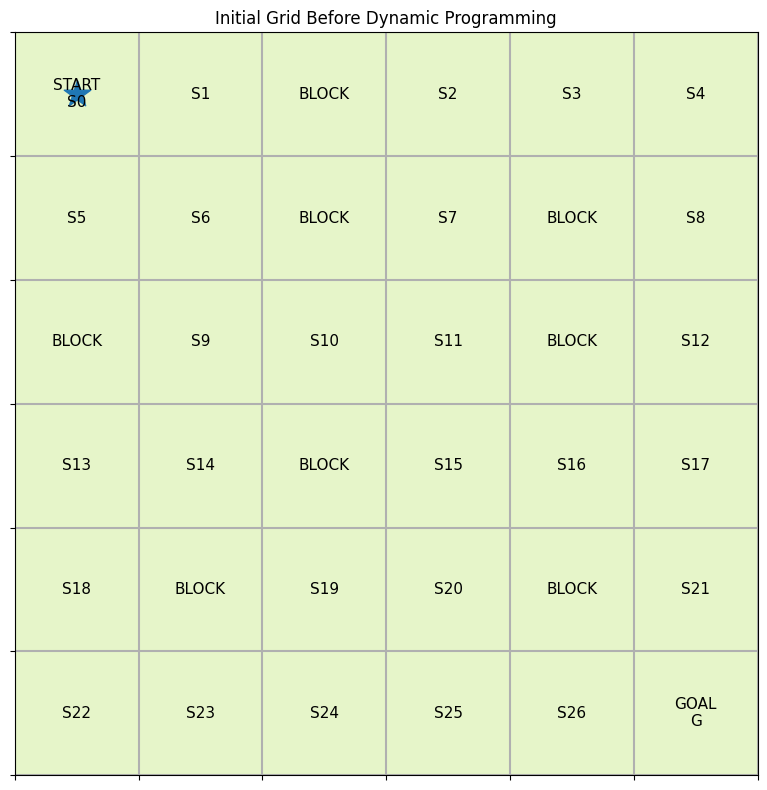

Iteration  1 | Largest Change = 15.800000

CURRENT POLICY AFTER ITERATION 1


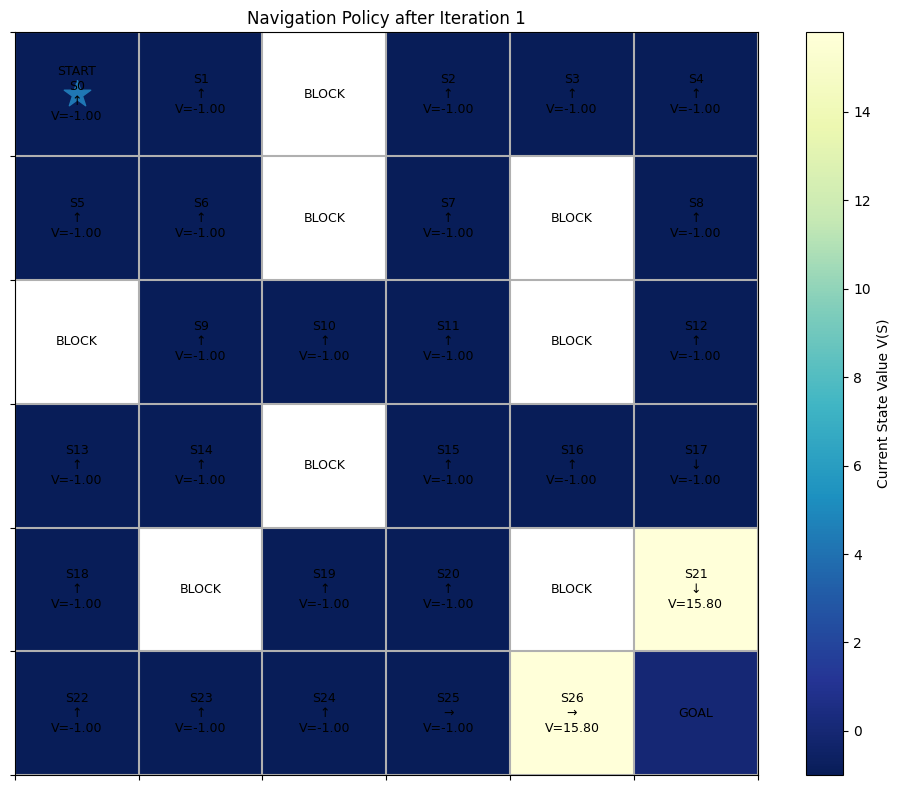


Current intended path after Iteration 1:
S0 -> S0
Iteration  2 | Largest Change = 11.196000
Iteration  3 | Largest Change = 7.899120
Iteration  4 | Largest Change = 6.325387
Iteration  5 | Largest Change = 4.423059

CURRENT POLICY AFTER ITERATION 5


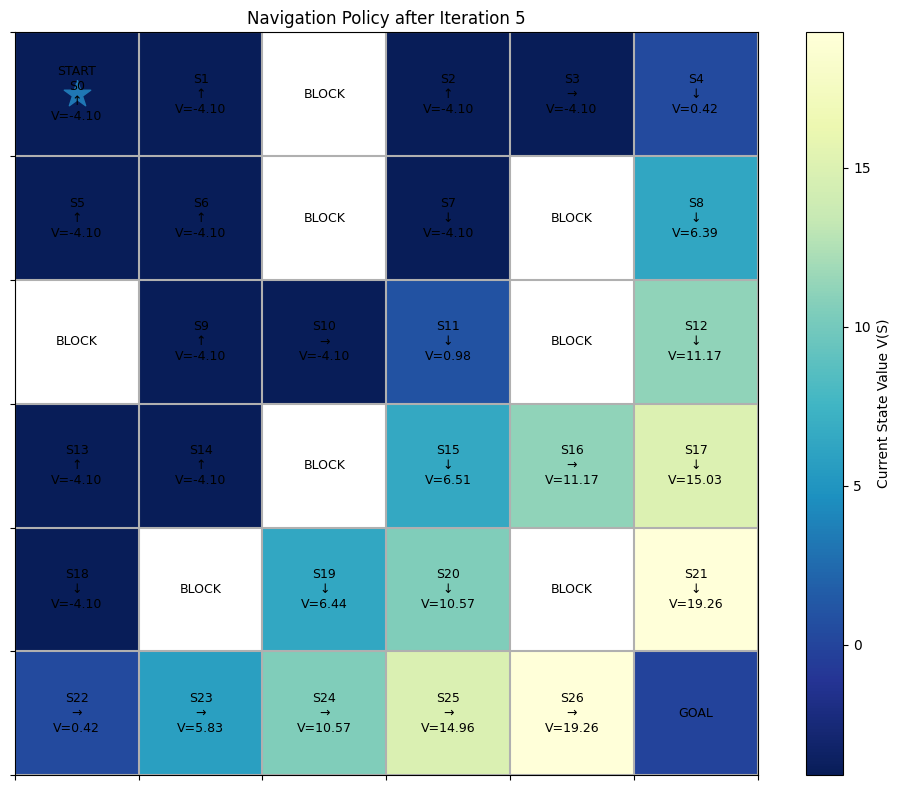


Current intended path after Iteration 5:
S0 -> S0
Iteration  6 | Largest Change = 3.066504
Iteration  7 | Largest Change = 2.533469
Iteration  8 | Largest Change = 2.095809
Iteration  9 | Largest Change = 1.531445
Iteration 10 | Largest Change = 1.315212

CURRENT POLICY AFTER ITERATION 10


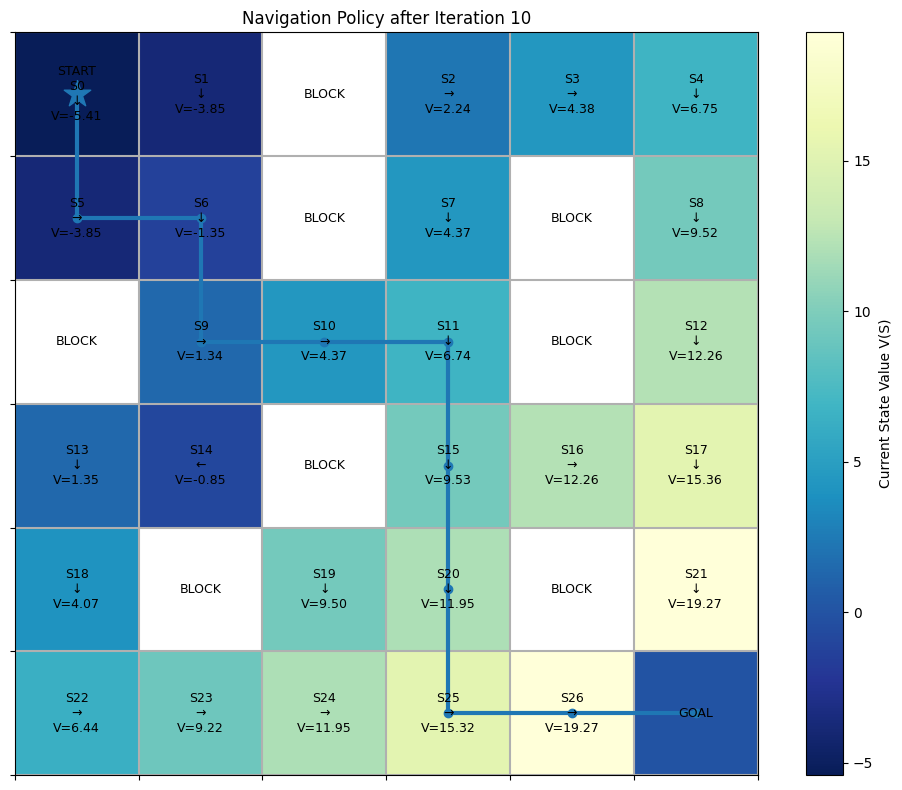


Current intended path after Iteration 10:
S0 -> S5 -> S6 -> S9 -> S10 -> S11 -> S15 -> S20 -> S25 -> S26 -> G
Iteration 11 | Largest Change = 1.042183
Iteration 12 | Largest Change = 0.916558
Iteration 13 | Largest Change = 0.713290
Iteration 14 | Largest Change = 0.540718
Iteration 15 | Largest Change = 0.362292

CURRENT POLICY AFTER ITERATION 15


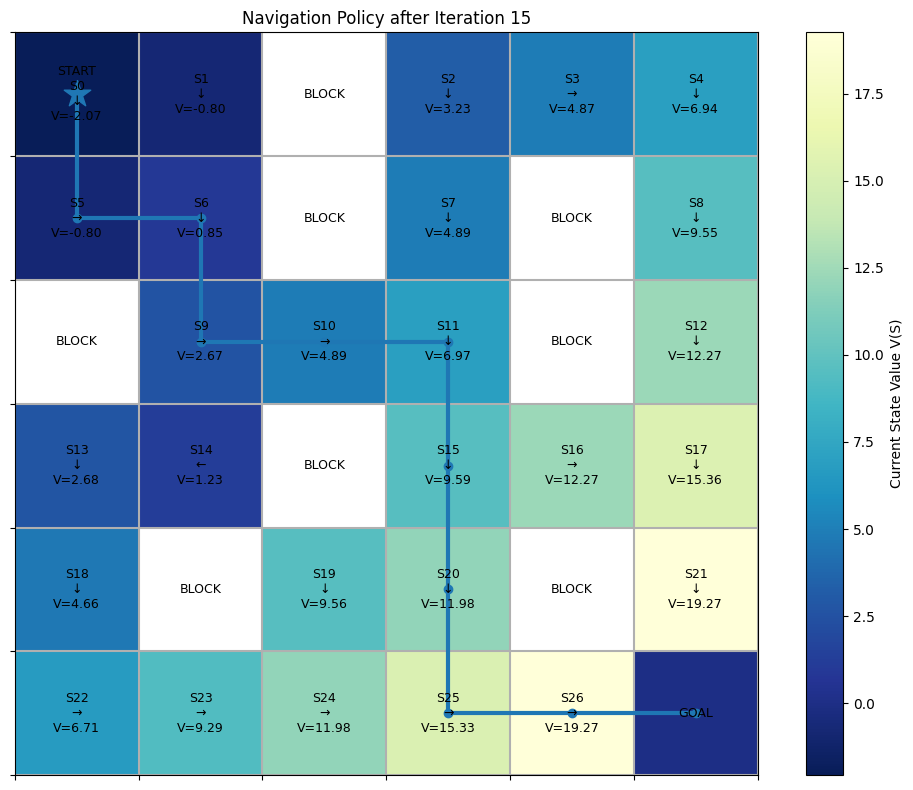


Current intended path after Iteration 15:
S0 -> S5 -> S6 -> S9 -> S10 -> S11 -> S15 -> S20 -> S25 -> S26 -> G
Iteration 16 | Largest Change = 0.236673
Iteration 17 | Largest Change = 0.145889
Iteration 18 | Largest Change = 0.087933
Iteration 19 | Largest Change = 0.051337
Iteration 20 | Largest Change = 0.029450

CURRENT POLICY AFTER ITERATION 20


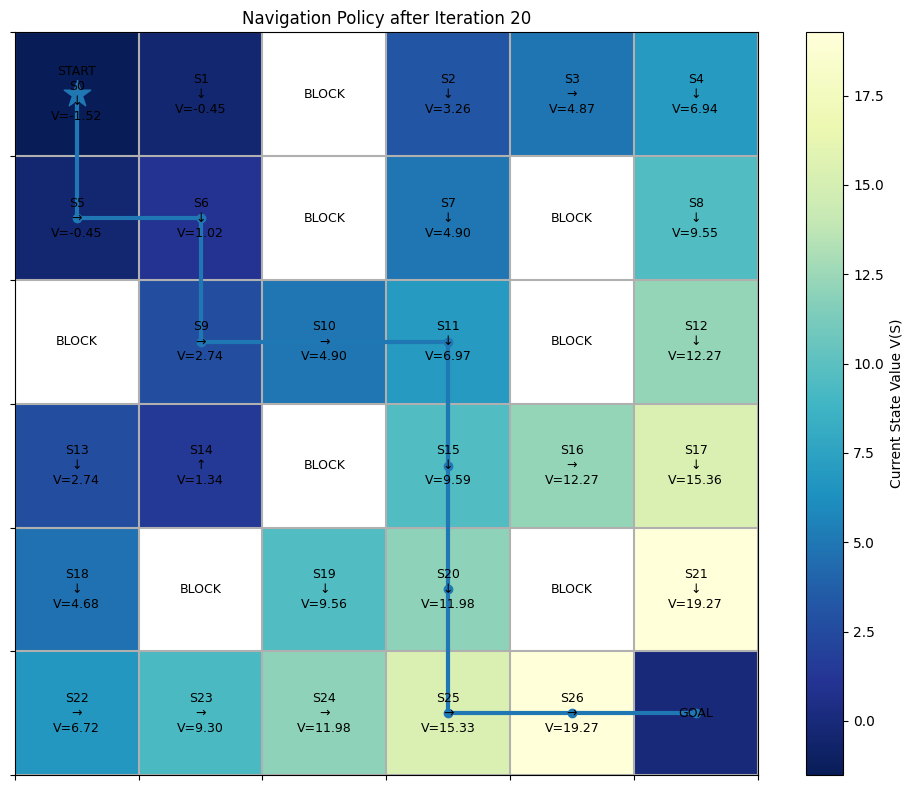


Current intended path after Iteration 20:
S0 -> S5 -> S6 -> S9 -> S10 -> S11 -> S15 -> S20 -> S25 -> S26 -> G
Iteration 21 | Largest Change = 0.016564
Iteration 22 | Largest Change = 0.009242
Iteration 23 | Largest Change = 0.005106
Iteration 24 | Largest Change = 0.002799
Iteration 25 | Largest Change = 0.001524

CURRENT POLICY AFTER ITERATION 25


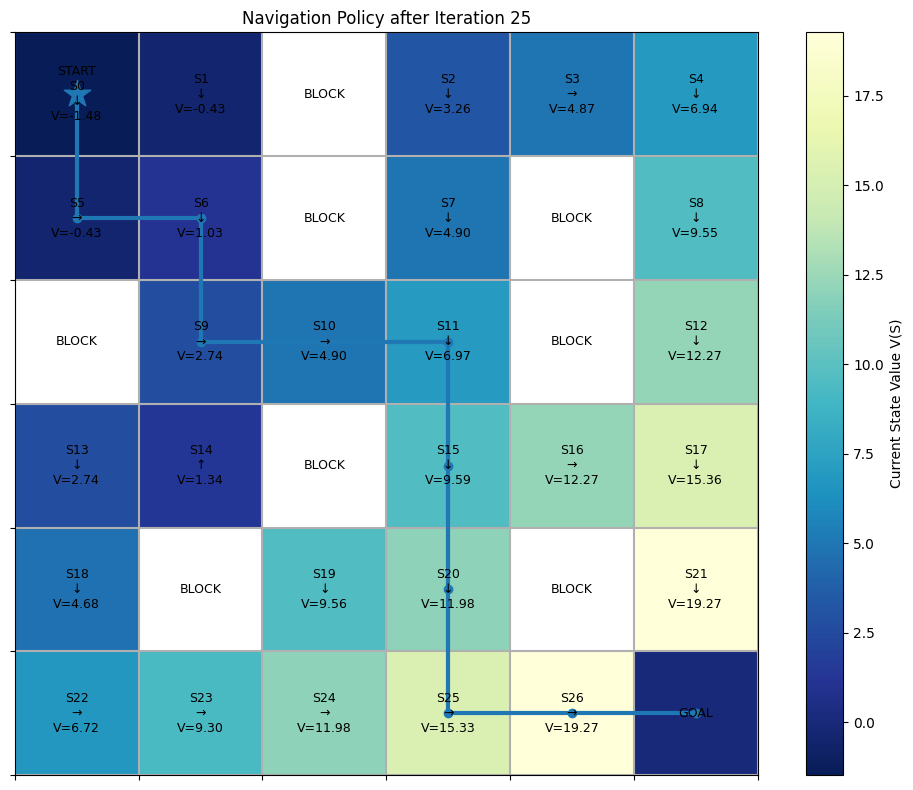


Current intended path after Iteration 25:
S0 -> S5 -> S6 -> S9 -> S10 -> S11 -> S15 -> S20 -> S25 -> S26 -> G
Iteration 26 | Largest Change = 0.000825
Iteration 27 | Largest Change = 0.000444
Iteration 28 | Largest Change = 0.000238
Iteration 29 | Largest Change = 0.000127
Iteration 30 | Largest Change = 0.000067

CURRENT POLICY AFTER ITERATION 30


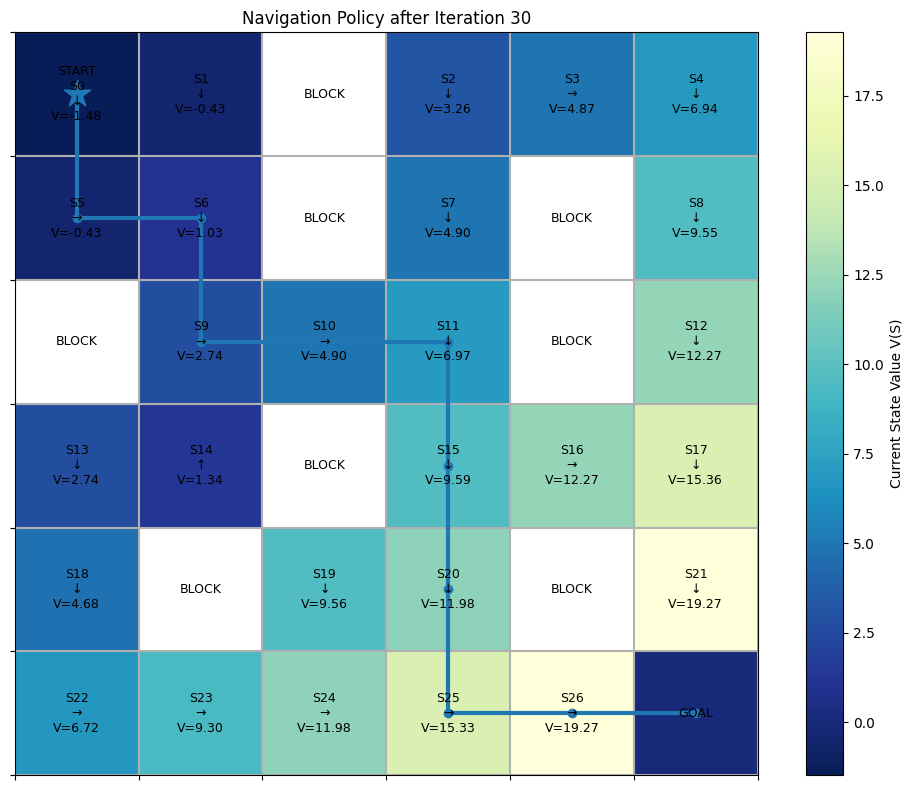


Current intended path after Iteration 30:
S0 -> S5 -> S6 -> S9 -> S10 -> S11 -> S15 -> S20 -> S25 -> S26 -> G
Iteration 31 | Largest Change = 0.000036
Iteration 32 | Largest Change = 0.000019
Iteration 33 | Largest Change = 0.000010

VALUE ITERATION CONVERGED
Total Iterations = 33

FINAL OPTIMAL PATH
S0 -> S5 -> S6 -> S9 -> S10 -> S11 -> S15 -> S20 -> S25 -> S26 -> G


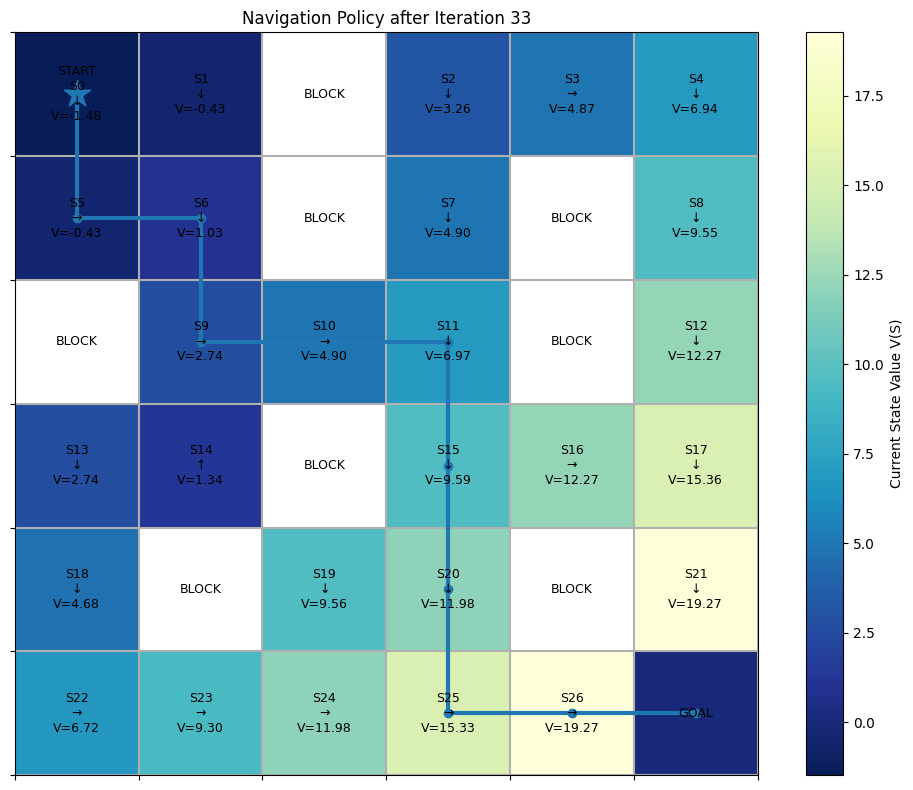


Current intended path after Iteration 33:
S0 -> S5 -> S6 -> S9 -> S10 -> S11 -> S15 -> S20 -> S25 -> S26 -> G


In [9]:
import matplotlib.pyplot as plt
import numpy as np


# ============================================================
# 1. GRID-WORLD
# ============================================================

grid = [
    ["S0",  "S1",  "X",   "S2",  "S3",  "S4"],
    ["S5",  "S6",  "X",   "S7",  "X",   "S8"],
    ["X",   "S9",  "S10", "S11", "X",   "S12"],
    ["S13", "S14", "X",   "S15", "S16", "S17"],
    ["S18", "X",   "S19", "S20", "X",   "S21"],
    ["S22", "S23", "S24", "S25", "S26", "G"]
]

number_of_rows = 6                  # Total number of rows
number_of_columns = 6               # Total number of columns

start_state = "S0"                  # START at top-left corner
goal_state = "G"                    # GOAL at bottom-right corner
blocked_state = "X"                 # Obstacle cell


# ============================================================
# 2. ACTIONS
# ============================================================

actions = {
    "a1": (-1, 0),                  # a1 = Up
    "a2": (1, 0),                   # a2 = Down
    "a3": (0, -1),                  # a3 = Left
    "a4": (0, 1)                    # a4 = Right
}

action_symbol = {
    "a1": "↑",
    "a2": "↓",
    "a3": "←",
    "a4": "→"
}


# ============================================================
# 3. VALUE-ITERATION PARAMETERS
# ============================================================

discount_factor = 0.9               # gamma: importance of future rewards
tolerance = 1e-5                    # Convergence threshold


# ============================================================
# 4. ENVIRONMENT UNCERTAINTY
# ============================================================

intended_move_probability = 0.8     # 80% chance intended action succeeds
slip_probability = 0.1              # 10% slip one side, 10% other side


# ============================================================
# 5. REWARDS
# ============================================================

normal_reward = -1                  # Cost for every normal move
goal_reward = 20                    # Reward for reaching goal


# ============================================================
# 6. STATE -> POSITION MAPPING
# ============================================================

state_position = {}                 # Maps state name to (row, column)

for row in range(number_of_rows):

    for column in range(number_of_columns):

        state = grid[row][column]

        if state != blocked_state:

            state_position[state] = (
                row,
                column
            )


# ============================================================
# 7. INITIAL STATE VALUES
# ============================================================

state_value = {}                    # Stores current V(S)

for state in state_position:

    state_value[state] = 0.0        # Initial estimate: no prior knowledge


state_value[goal_state] = 0.0       # Goal is terminal, so no future value


# ============================================================
# 8. SIDE ACTIONS
# ============================================================

def get_side_actions(selected_action):

    if selected_action == "a1":     # Up
        return "a3", "a4"           # Left, Right

    elif selected_action == "a2":   # Down
        return "a3", "a4"           # Left, Right

    elif selected_action == "a3":   # Left
        return "a1", "a2"           # Up, Down

    elif selected_action == "a4":   # Right
        return "a1", "a2"           # Up, Down


# ============================================================
# 9. MOVE FUNCTION
# ============================================================

def move(current_state, actual_action):

    current_row, current_column = state_position[current_state]
    # Current position of the agent

    row_change, column_change = actions[actual_action]
    # Movement associated with this action

    next_row = current_row + row_change
    next_column = current_column + column_change


    # --------------------------------------------------------
    # HIT WALL -> REMAIN IN SAME STATE
    # --------------------------------------------------------

    if (
        next_row < 0
        or next_row >= number_of_rows
        or next_column < 0
        or next_column >= number_of_columns
    ):

        return current_state


    next_cell = grid[next_row][next_column]


    # --------------------------------------------------------
    # HIT BLOCKED CELL -> REMAIN IN SAME STATE
    # --------------------------------------------------------

    if next_cell == blocked_state:

        return current_state


    return next_cell


# ============================================================
# 10. REWARD FUNCTION
# ============================================================

def get_reward(next_state):

    if next_state == goal_state:

        return goal_reward           # +20 for reaching goal

    else:

        return normal_reward         # -1 for normal movement


# ============================================================
# 11. EXPECTED RETURN FOR ONE ACTION
# ============================================================

def calculate_expected_return(
    current_state,
    selected_action,
    value_estimate
):

    expected_return_for_action = 0.0
    # Running expected return for this action


    side_action_1, side_action_2 = get_side_actions(
        selected_action
    )


    possible_environment_outcomes = [

        (
            intended_move_probability,
            selected_action
        ),

        (
            slip_probability,
            side_action_1
        ),

        (
            slip_probability,
            side_action_2
        )
    ]


    for (
        transition_probability,
        actual_action
    ) in possible_environment_outcomes:


        next_state = move(
            current_state,
            actual_action
        )
        # State reached after this environment outcome


        received_reward = get_reward(
            next_state
        )
        # Immediate reward r


        one_outcome_return = (
            received_reward
            + discount_factor
            * value_estimate[next_state]
        )
        # r + gamma * V(S')


        probability_weighted_return = (
            transition_probability
            * one_outcome_return
        )
        # P(S',r|S,a) * [r + gamma V(S')]


        expected_return_for_action += (
            probability_weighted_return
        )


    return expected_return_for_action


# ============================================================
# 12. GET CURRENT BEST POLICY
# ============================================================

def get_best_policy(value_estimate):

    current_policy = {}
    # Stores current best action for each state


    for current_state in state_position:


        if current_state == goal_state:

            continue


        action_returns = {}
        # Expected return of every possible action


        for selected_action in actions:

            action_returns[selected_action] = (
                calculate_expected_return(
                    current_state,
                    selected_action,
                    value_estimate
                )
            )


        best_action = max(
            action_returns,
            key=action_returns.get
        )
        # Select action with highest expected return


        current_policy[current_state] = (
            best_action
        )


    return current_policy


# ============================================================
# 13. GET INTENDED NAVIGATION PATH
# ============================================================

def get_navigation_path(current_policy):

    current_state = start_state     # Begin from START

    navigation_path = [
        current_state
    ]                               # Stores visited states

    maximum_steps = 60              # Prevent infinite loops


    for step in range(maximum_steps):


        if current_state == goal_state:

            break


        selected_action = current_policy[
            current_state
        ]
        # Current best action


        next_state = move(
            current_state,
            selected_action
        )
        # Follow intended action only for displaying current policy


        navigation_path.append(
            next_state
        )


        # Stop if current policy creates a loop
        if (
            next_state in navigation_path[:-1]
            and next_state != goal_state
        ):

            break


        current_state = next_state


    return navigation_path


# ============================================================
# 14. INITIAL GRID VISUALIZATION
# ============================================================

def visualize_initial_grid():

    background_matrix = np.ones(
        (
            number_of_rows,
            number_of_columns
        )
    )
    # Simple light background


    plt.figure(
        figsize=(10, 8)
    )


    plt.imshow(
        background_matrix,
        cmap="Pastel2",
        vmin=0,
        vmax=2
    )
    # Light pastel background


    for row in range(number_of_rows):

        for column in range(number_of_columns):

            state = grid[row][column]


            if state == blocked_state:

                cell_text = "BLOCK"


            elif state == start_state:

                cell_text = (
                    f"START\n"
                    f"{state}"
                )


            elif state == goal_state:

                cell_text = (
                    f"GOAL\n"
                    f"{state}"
                )


            else:

                cell_text = state


            plt.text(
                column,
                row,
                cell_text,
                ha="center",
                va="center",
                fontsize=11
            )


    start_row, start_column = state_position[
        start_state
    ]


    plt.scatter(
        start_column,
        start_row,
        s=400,
        marker="*"
    )


    # Draw clear cell boundaries
    plt.xticks(
        np.arange(-0.5, number_of_columns, 1),
        []
    )

    plt.yticks(
        np.arange(-0.5, number_of_rows, 1),
        []
    )

    plt.grid(
        True,
        linewidth=1.5
    )


    plt.title(
        "Initial Grid Before Dynamic Programming"
    )


    plt.tight_layout()

    plt.show()


# ============================================================
# 15. VISUALIZE CURRENT POLICY
# ============================================================

def visualize_policy(
    iteration_number,
    value_estimate,
    current_policy
):

    navigation_path = get_navigation_path(
        current_policy
    )


    value_matrix = np.full(
        (
            number_of_rows,
            number_of_columns
        ),
        np.nan
    )


    for row in range(number_of_rows):

        for column in range(number_of_columns):

            state = grid[row][column]


            if state == blocked_state:

                continue


            elif state == goal_state:

                value_matrix[
                    row,
                    column
                ] = 0.0


            else:

                value_matrix[
                    row,
                    column
                ] = value_estimate[state]


    plt.figure(
        figsize=(10, 8)
    )


    plt.imshow(
        value_matrix,
        cmap="YlGnBu_r"
    )
    # Light color map:
    # higher values appear lighter


    plt.colorbar(
        label="Current State Value V(S)"
    )


    # --------------------------------------------------------
    # DISPLAY STATE, ACTION AND VALUE
    # --------------------------------------------------------

    for row in range(number_of_rows):

        for column in range(number_of_columns):

            state = grid[row][column]


            if state == blocked_state:

                cell_text = "BLOCK"


            elif state == goal_state:

                cell_text = "GOAL"


            else:

                arrow = action_symbol[
                    current_policy[state]
                ]


                if state == start_state:

                    cell_text = (
                        f"START\n"
                        f"{state}\n"
                        f"{arrow}\n"
                        f"V={value_estimate[state]:.2f}"
                    )

                else:

                    cell_text = (
                        f"{state}\n"
                        f"{arrow}\n"
                        f"V={value_estimate[state]:.2f}"
                    )


            plt.text(
                column,
                row,
                cell_text,
                ha="center",
                va="center",
                fontsize=9
            )


    # --------------------------------------------------------
    # DRAW CURRENT PATH FROM START
    # --------------------------------------------------------

    path_x = []
    path_y = []


    for state in navigation_path:

        if state in state_position:

            row, column = state_position[state]

            path_x.append(column)
            path_y.append(row)


    if len(path_x) > 1:

        plt.plot(
            path_x,
            path_y,
            linewidth=3,
            marker="o"
        )


    # Mark starting point
    start_row, start_column = state_position[
        start_state
    ]


    plt.scatter(
        start_column,
        start_row,
        s=400,
        marker="*"
    )


    # Draw cell boundaries
    plt.xticks(
        np.arange(-0.5, number_of_columns, 1),
        []
    )

    plt.yticks(
        np.arange(-0.5, number_of_rows, 1),
        []
    )

    plt.grid(
        True,
        linewidth=1.5
    )


    plt.title(
        f"Navigation Policy after Iteration {iteration_number}"
    )


    plt.tight_layout()

    plt.show()


    print(
        f"\nCurrent intended path after Iteration {iteration_number}:"
    )

    print(
        " -> ".join(navigation_path)
    )


# ============================================================
# 16. SHOW INITIAL ENVIRONMENT
# ============================================================

print(
    "\nINITIAL GRID BEFORE DYNAMIC PROGRAMMING"
)

visualize_initial_grid()


# ============================================================
# 17. VALUE ITERATION
# ============================================================

iteration_number = 0              # Number of completed iterations


while True:


    iteration_number += 1


    previous_state_value = state_value.copy()
    # Store V_k(S)


    largest_change = 0.0
    # Largest state-value change this iteration


    for current_state in state_position:


        if current_state == goal_state:

            continue


        action_returns = {}
        # Expected return for each action


        for selected_action in actions:


            action_returns[selected_action] = (
                calculate_expected_return(
                    current_state,
                    selected_action,
                    previous_state_value
                )
            )


        # ----------------------------------------------------
        # BELLMAN OPTIMALITY
        #
        # Choose the action with the largest expected return
        # ----------------------------------------------------

        best_action_value = max(
            action_returns.values()
        )


        state_value[
            current_state
        ] = best_action_value


        current_state_change = abs(
            state_value[current_state]
            - previous_state_value[current_state]
        )


        largest_change = max(
            largest_change,
            current_state_change
        )


    print(
        f"Iteration {iteration_number:2d} | "
        f"Largest Change = {largest_change:.6f}"
    )


    # ========================================================
    # SHOW ITERATION 1 AND THEN EVERY 5 ITERATIONS
    # ========================================================

    if (
        iteration_number == 1
        or iteration_number % 5 == 0
    ):


        current_policy = get_best_policy(
            state_value
        )


        print(
            "\n" + "=" * 70
        )

        print(
            f"CURRENT POLICY AFTER ITERATION {iteration_number}"
        )

        print(
            "=" * 70
        )


        visualize_policy(
            iteration_number,
            state_value,
            current_policy
        )


    # ========================================================
    # CHECK CONVERGENCE
    # ========================================================

    if largest_change < tolerance:

        break


# ============================================================
# 18. FINAL OPTIMAL POLICY
# ============================================================

optimal_policy = get_best_policy(
    state_value
)


optimal_path = get_navigation_path(
    optimal_policy
)


print(
    "\n" + "=" * 70
)

print(
    "VALUE ITERATION CONVERGED"
)

print(
    "=" * 70
)


print(
    f"Total Iterations = {iteration_number}"
)


print(
    "\nFINAL OPTIMAL PATH"
)


print(
    " -> ".join(optimal_path)
)


# ============================================================
# 19. FINAL VISUALIZATION
# ============================================================

visualize_policy(
    iteration_number,
    state_value,
    optimal_policy
)

# Q learning

In [ ]:
import random


# ============================================================
# 1. AVAILABLE ACTIONS AT EACH STATE
# ============================================================

actions_by_state = {

    "A": ["a1", "a2"],          # At A, the agent can choose a1 or a2

    "B": ["a1"],                # At B, only a1 is available

    "T": []                     # T is terminal, so no action is available
}


# ============================================================
# 2. ENVIRONMENT
#
# Each entry means:
# (current_state, action) -> (next_state, reward)
# ============================================================

environment = {

    ("A", "a1"): ("B", 2),      # A --a1--> B with reward +2

    ("A", "a2"): ("T", 5),      # A --a2--> T with reward +5

    ("B", "a1"): ("T", 10)      # B --a1--> T with reward +10
}


# ============================================================
# 3. Q-LEARNING PARAMETERS
# ============================================================

learning_rate = 0.5             # alpha: how much new experience changes Q(S,a)

discount_factor = 0.9           # gamma: importance of future rewards

exploration_rate = 0.2          # epsilon: probability of exploration

number_of_episodes = 10         # Number of complete training episodes


# ============================================================
# 4. INITIAL Q-TABLE
#
# The agent initially knows nothing.
# Therefore every action value starts at 0.
# ============================================================

q_table = {

    "A": {
        "a1": 0.0,              # Initial estimate Q(A,a1)
        "a2": 0.0               # Initial estimate Q(A,a2)
    },

    "B": {
        "a1": 0.0               # Initial estimate Q(B,a1)
    }
}


# ============================================================
# 5. FUNCTION TO DISPLAY Q-TABLE
# ============================================================

def display_q_table():

    print("\nQ-TABLE")

    print(f"{'State':<10}{'a1':>12}{'a2':>12}")
    print("-" * 34)

    print(
        f"{'A':<10}"
        f"{q_table['A']['a1']:>12.3f}"
        f"{q_table['A']['a2']:>12.3f}"
    )

    print(
        f"{'B':<10}"
        f"{q_table['B']['a1']:>12.3f}"
        f"{'-':>12}"
    )


# ============================================================
# 6. DISPLAY INITIAL Q-TABLE
# ============================================================

print("\nINITIAL Q-TABLE")

display_q_table()


# ============================================================
# 7. TRAINING
# ============================================================

for episode_number in range(1, number_of_episodes + 1):


    current_state = "A"
    # Every episode begins from state A


    print("\n" + "=" * 60)

    print(
        f"EPISODE {episode_number}"
    )

    print("=" * 60)


    # --------------------------------------------------------
    # Continue until terminal state T is reached
    # --------------------------------------------------------

    while current_state != "T":


        # ====================================================
        # 8. EPSILON-GREEDY ACTION SELECTION
        # ====================================================

        generated_random_number = random.random()
        # Produces a random number between 0 and 1


        if generated_random_number < exploration_rate:


            selected_action = random.choice(
                actions_by_state[current_state]
            )
            # Exploration:
            # choose one available action randomly


            decision_type = "Exploration"


        else:


            selected_action = max(
                q_table[current_state],
                key=q_table[current_state].get
            )
            # Exploitation:
            # choose the action with the highest current Q-value


            decision_type = "Exploitation"


        print(
            f"\nCurrent State        : {current_state}"
        )

        print(
            f"Random Number        : {generated_random_number:.3f}"
        )

        print(
            f"Decision             : {decision_type}"
        )

        print(
            f"Selected Action      : {selected_action}"
        )


        # ====================================================
        # 9. INTERACT WITH ENVIRONMENT
        # ====================================================

        next_state, received_reward = environment[
            (current_state, selected_action)
        ]
        # Environment returns:
        # next_state = S'
        # received_reward = r


        print(
            f"Next State           : {next_state}"
        )

        print(
            f"Received Reward      : {received_reward}"
        )


        # ====================================================
        # 10. FIND BEST FUTURE Q-VALUE
        # ====================================================

        if next_state == "T":


            best_future_q_value = 0.0
            # Terminal state has no future action
            # Therefore future Q-value contribution is 0


        else:


            best_future_q_value = max(
                q_table[next_state].values()
            )
            # Find:
            #
            # max Q(S',a')


        print(
            f"Best Future Q-value  : {best_future_q_value:.3f}"
        )


        # ====================================================
        # 11. CALCULATE Q-LEARNING TARGET
        #
        # Target =
        # r + gamma * max Q(S',a')
        # ====================================================

        target_q_value = (
            received_reward
            + discount_factor
            * best_future_q_value
        )


        print(
            f"Target Q-value       : {target_q_value:.3f}"
        )


        # ====================================================
        # 12. GET CURRENT Q-VALUE
        # ====================================================

        current_q_value = q_table[
            current_state
        ][
            selected_action
        ]
        # Current estimate Q(S,a)


        print(
            f"Current Q-value      : {current_q_value:.3f}"
        )


        # ====================================================
    # 13. CALCULATE DIFFERENCE BETWEEN TARGET AND CURRENT
    # ====================================================
    
    q_value_error = (
        target_q_value
        - current_q_value
    )
    # Error = Target - Current Q-value
    
    
    print(
        f"Q-value Error        : {q_value_error:.3f}"
    )
    
    
    # ====================================================
    # 14. SHOW Q-LEARNING EQUATION WITH SUBSTITUTION
    # ====================================================
    
    print("\nQ-learning Update Equation:")
    
    print(
        "Q_new(S,a) = Q_old(S,a) "
        "+ alpha * [r + gamma * max Q(S',a') - Q_old(S,a)]"
    )
    
    print("\nSubstitution:")
    
    print(
        f"Q_new({current_state},{selected_action}) "
        f"= {current_q_value:.3f} "
        f"+ {learning_rate:.3f} * "
        f"[{received_reward:.3f} "
        f"+ {discount_factor:.3f} * {best_future_q_value:.3f} "
        f"- {current_q_value:.3f}]"
    )
    
    
    # ====================================================
    # 15. CALCULATE UPDATED Q-VALUE
    # ====================================================
    
    updated_q_value = (
        current_q_value
        + learning_rate
        * q_value_error
    )
    
    
    print("\nAfter calculating the target:")
    
    print(
        f"Q_new({current_state},{selected_action}) "
        f"= {current_q_value:.3f} "
        f"+ {learning_rate:.3f} "
        f"* ({target_q_value:.3f} - {current_q_value:.3f})"
    )
    
    
    print(
        f"Q_new({current_state},{selected_action}) "
        f"= {updated_q_value:.3f}"
    )
    
    
    print(
        f"\nUpdated Q-value      : {updated_q_value:.3f}"
    )
    
    
    # ====================================================
    # 16. STORE UPDATED VALUE
    # ====================================================
    
    q_table[
        current_state
    ][
        selected_action
    ] = updated_q_value

    # ========================================================
    # 17. DISPLAY Q-TABLE AFTER EACH EPISODE
    # ========================================================

    print(
        f"\nQ-TABLE AFTER EPISODE {episode_number}"
    )

    display_q_table()


# ============================================================
# 18. FINAL LEARNED Q-TABLE
# ============================================================

print("\n" + "=" * 60)

print("FINAL LEARNED Q-TABLE")

print("=" * 60)

display_q_table()


# ============================================================
# 19. FINAL GREEDY POLICY
# ============================================================

print("\nBEST ACTION LEARNED AT EACH STATE")


for state in ["A", "B"]:


    best_action = max(
        q_table[state],
        key=q_table[state].get
    )
    # Action with maximum Q-value in this state


    print(
        f"State {state} -> {best_action}"
    )


INITIAL Q-TABLE

Q-TABLE
State               a1          a2
----------------------------------
A                0.000       0.000
B                0.000           -

EPISODE 1

Current State        : A
Random Number        : 0.487
Decision             : Exploitation
Selected Action      : a1
Next State           : B
Received Reward      : 2
Best Future Q-value  : 0.000
Target Q-value       : 2.000
Current Q-value      : 0.000

Current State        : A
Random Number        : 0.924
Decision             : Exploitation
Selected Action      : a1
Next State           : B
Received Reward      : 2
Best Future Q-value  : 0.000
Target Q-value       : 2.000
Current Q-value      : 0.000

Current State        : A
Random Number        : 0.338
Decision             : Exploitation
Selected Action      : a1
Next State           : B
Received Reward      : 2
Best Future Q-value  : 0.000
Target Q-value       : 2.000
Current Q-value      : 0.000

Current State        : A
Random Number        : 0.493
Decisi

# Hazardouis Env


INITIAL WAREHOUSE


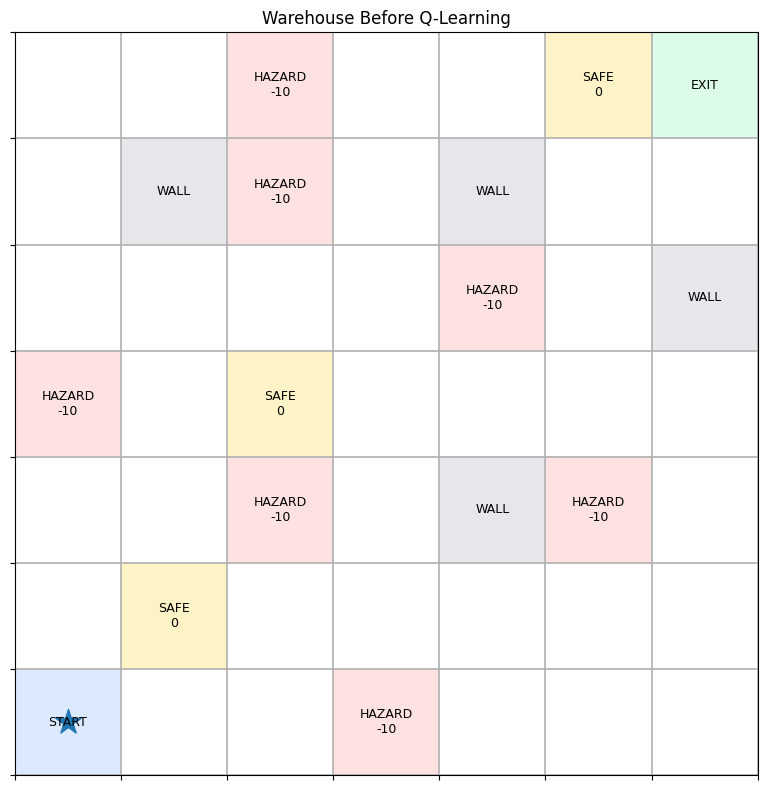


Episode 1 | Step 1
Current State          : (6, 0)
Random Number          : 0.324
Decision               : Exploitation
Selected Action        : DOWN
Next State             : (6, 0)
Reward                 : -3
Current Q-value        : 0.000
Best Future Q-value    : 0.000
Target Q-value         : -3.000

Q-learning Equation:
Q_new(S,a) = Q_old(S,a) + alpha * [r + gamma * max Q(S',a') - Q_old(S,a)]

Numerical Substitution:
Q_new((6, 0),DOWN) = 0.000 + 0.500 * [-3.000 + 0.900 * 0.000 - 0.000]

Simplified:
Q_new((6, 0),DOWN) = 0.000 + 0.500 * (-3.000)
Q_new((6, 0),DOWN) = -1.500

Episode 1 | Step 2
Current State          : (6, 0)
Random Number          : 0.395
Decision               : Exploitation
Selected Action        : UP
Next State             : (5, 0)
Reward                 : -1
Current Q-value        : 0.000
Best Future Q-value    : 0.000
Target Q-value         : -1.000

Q-learning Equation:
Q_new(S,a) = Q_old(S,a) + alpha * [r + gamma * max Q(S',a') - Q_old(S,a)]

Numerical Substit

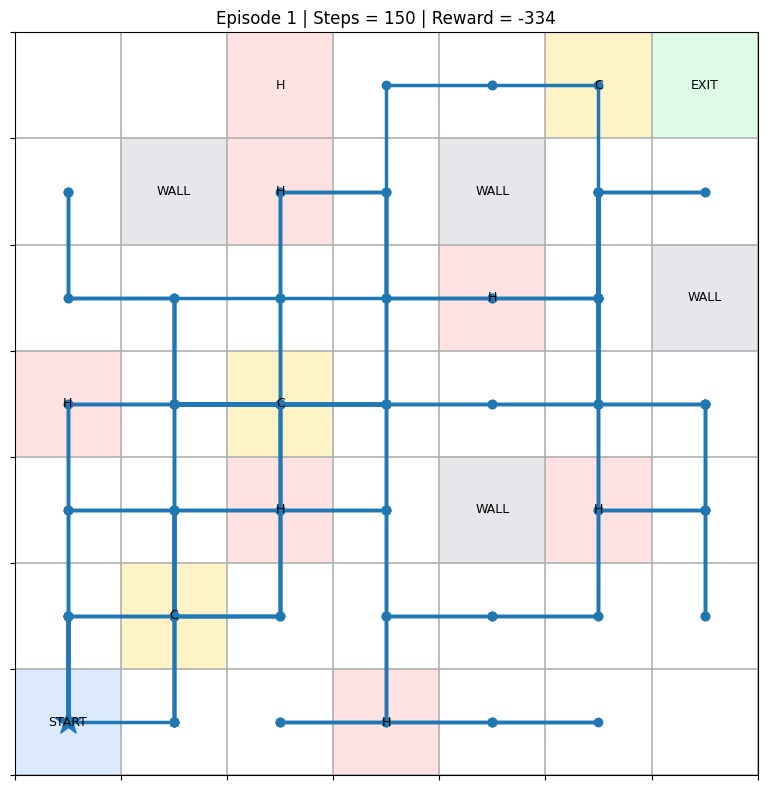


Episode 2 | Step 1
Current State          : (6, 0)
Random Number          : 0.508
Decision               : Exploitation
Selected Action        : RIGHT
Next State             : (6, 1)
Reward                 : -1
Current Q-value        : -0.750
Best Future Q-value    : 0.000
Target Q-value         : -1.000

Q-learning Equation:
Q_new(S,a) = Q_old(S,a) + alpha * [r + gamma * max Q(S',a') - Q_old(S,a)]

Numerical Substitution:
Q_new((6, 0),RIGHT) = -0.750 + 0.500 * [-1.000 + 0.900 * 0.000 - -0.750]

Simplified:
Q_new((6, 0),RIGHT) = -0.750 + 0.500 * (-0.250)
Q_new((6, 0),RIGHT) = -0.875

Episode 2 | Step 2
Current State          : (6, 1)
Random Number          : 0.508
Decision               : Exploitation
Selected Action        : UP
Next State             : (5, 1)
Reward                 : 0
Current Q-value        : 0.000
Best Future Q-value    : -0.750
Target Q-value         : -0.675

Q-learning Equation:
Q_new(S,a) = Q_old(S,a) + alpha * [r + gamma * max Q(S',a') - Q_old(S,a)]

Numerical

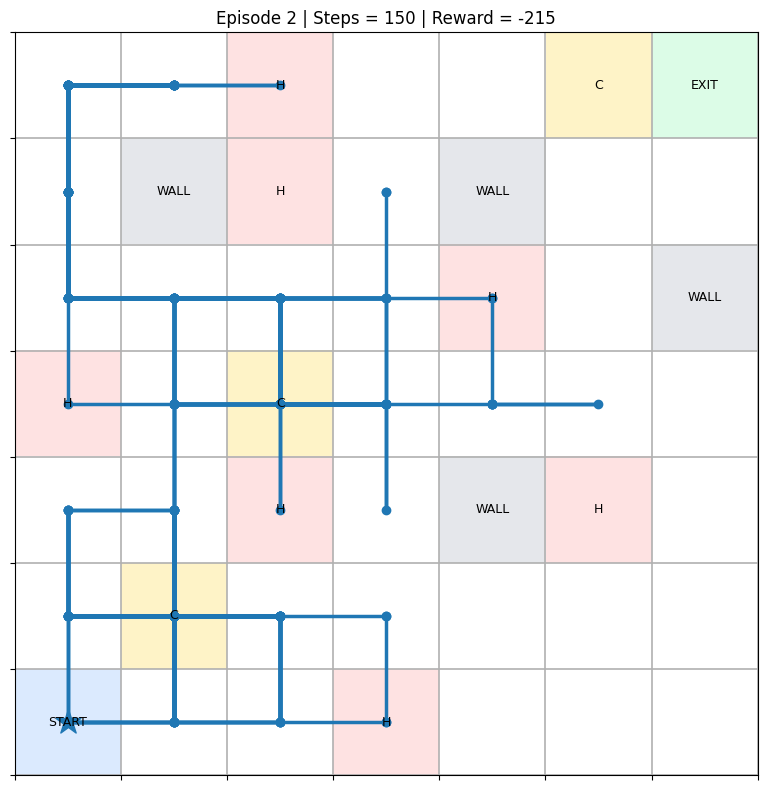


Episode 3 | Step 1
Current State          : (6, 0)
Random Number          : 0.933
Decision               : Exploitation
Selected Action        : UP
Next State             : (5, 0)
Reward                 : -1
Current Q-value        : -1.100
Best Future Q-value    : -0.963
Target Q-value         : -1.867

Q-learning Equation:
Q_new(S,a) = Q_old(S,a) + alpha * [r + gamma * max Q(S',a') - Q_old(S,a)]

Numerical Substitution:
Q_new((6, 0),UP) = -1.100 + 0.500 * [-1.000 + 0.900 * -0.963 - -1.100]

Simplified:
Q_new((6, 0),UP) = -1.100 + 0.500 * (-0.767)
Q_new((6, 0),UP) = -1.483

Episode 3 | Step 2
Current State          : (5, 0)
Random Number          : 0.451
Decision               : Exploitation
Selected Action        : RIGHT
Next State             : (5, 1)
Reward                 : 0
Current Q-value        : -0.963
Best Future Q-value    : -1.334
Target Q-value         : -1.201

Q-learning Equation:
Q_new(S,a) = Q_old(S,a) + alpha * [r + gamma * max Q(S',a') - Q_old(S,a)]

Numerical Subst

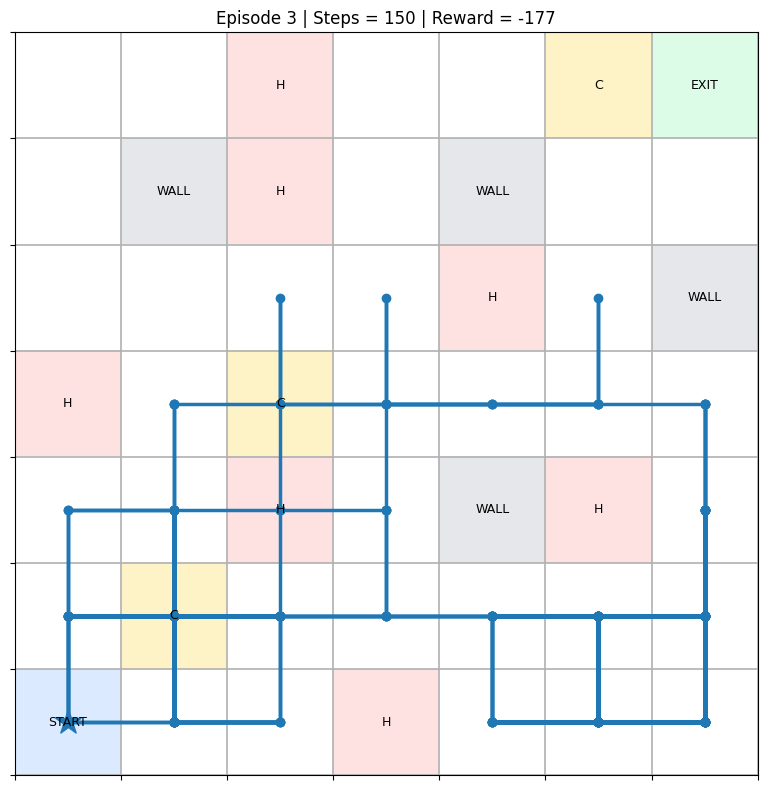


EPISODE 4 COMPLETED
Steps taken    : 88
Total reward   : -152
Reached EXIT   : True


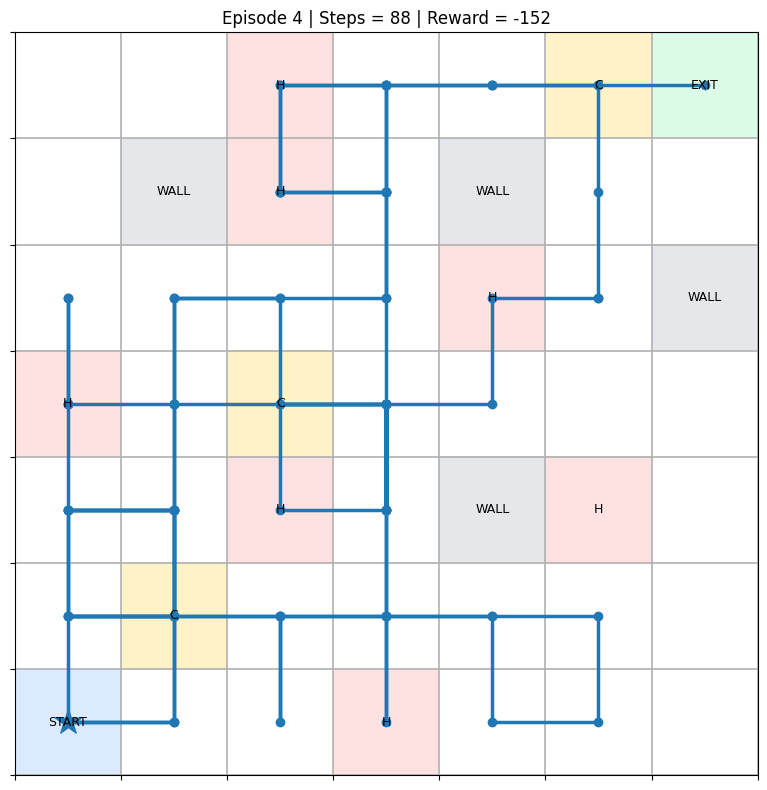


EPISODE 5 COMPLETED
Steps taken    : 69
Total reward   : -51
Reached EXIT   : True


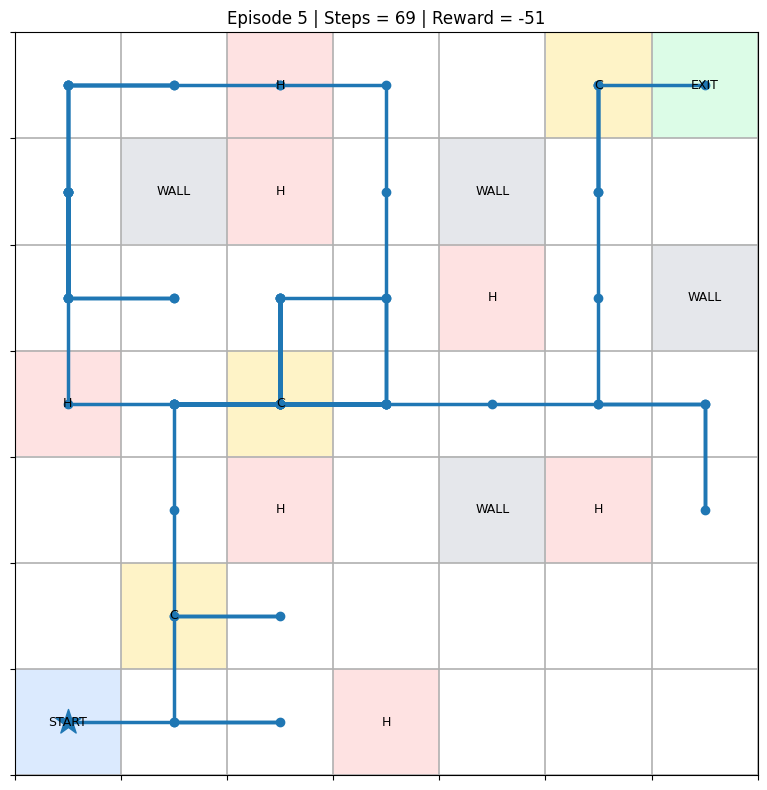


EPISODE 6 COMPLETED
Steps taken    : 82
Total reward   : -45
Reached EXIT   : True


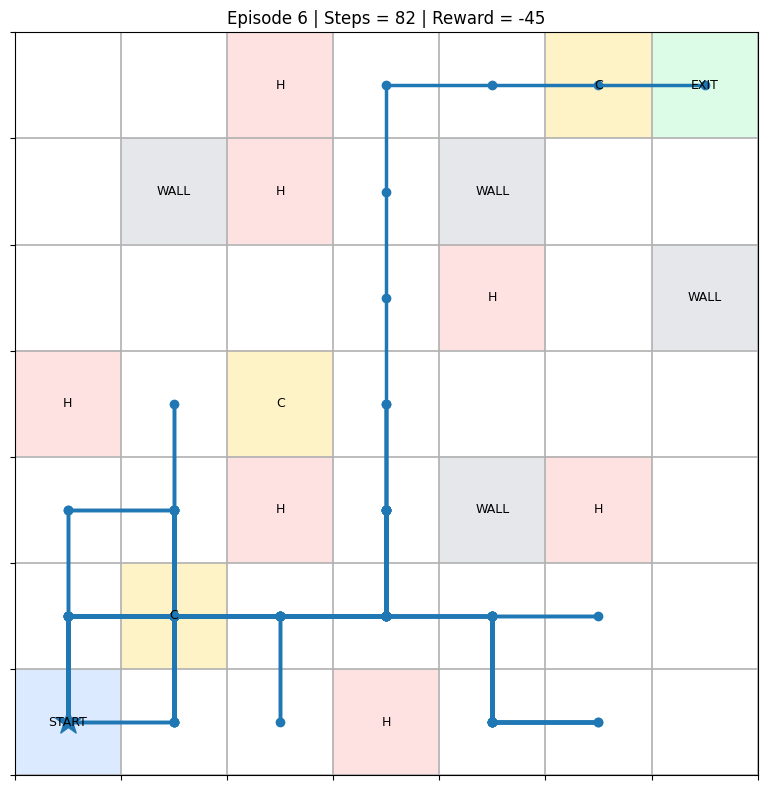


EPISODE 7 COMPLETED
Steps taken    : 73
Total reward   : -38
Reached EXIT   : True


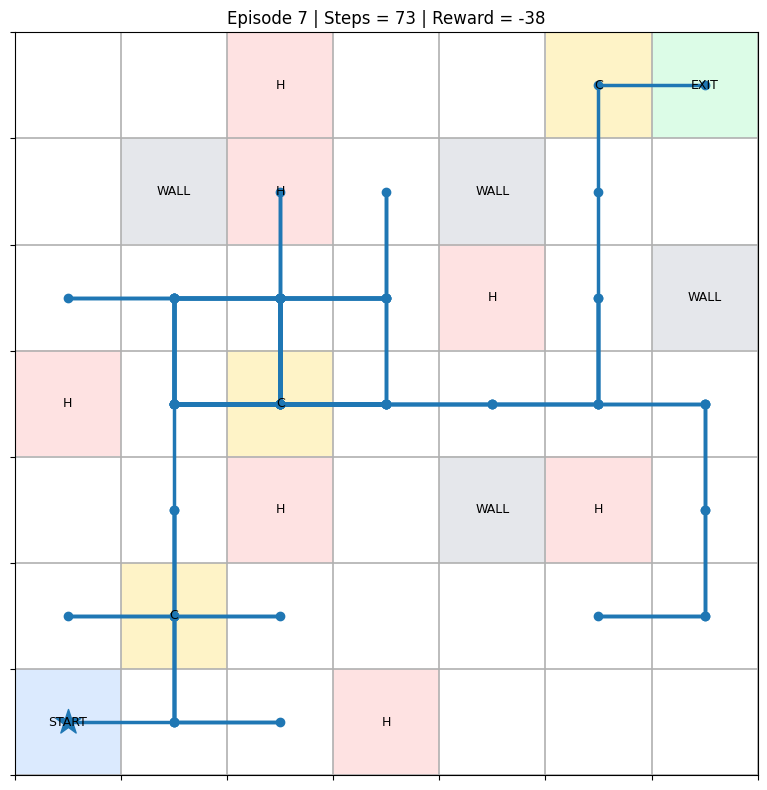


EPISODE 8 COMPLETED
Steps taken    : 89
Total reward   : -51
Reached EXIT   : True


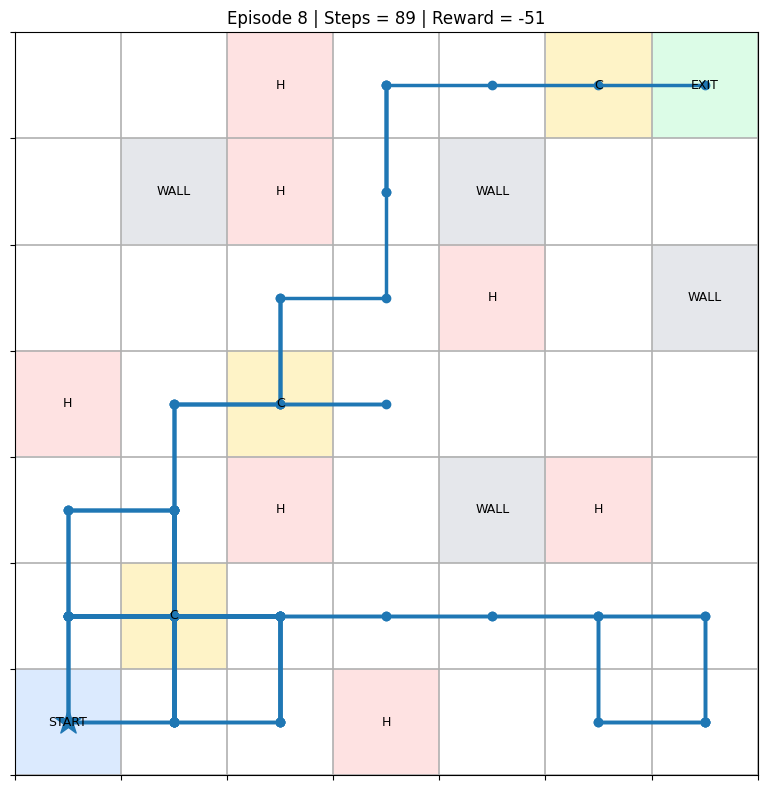


EPISODE 9 COMPLETED
Steps taken    : 14
Total reward   : 19
Reached EXIT   : True


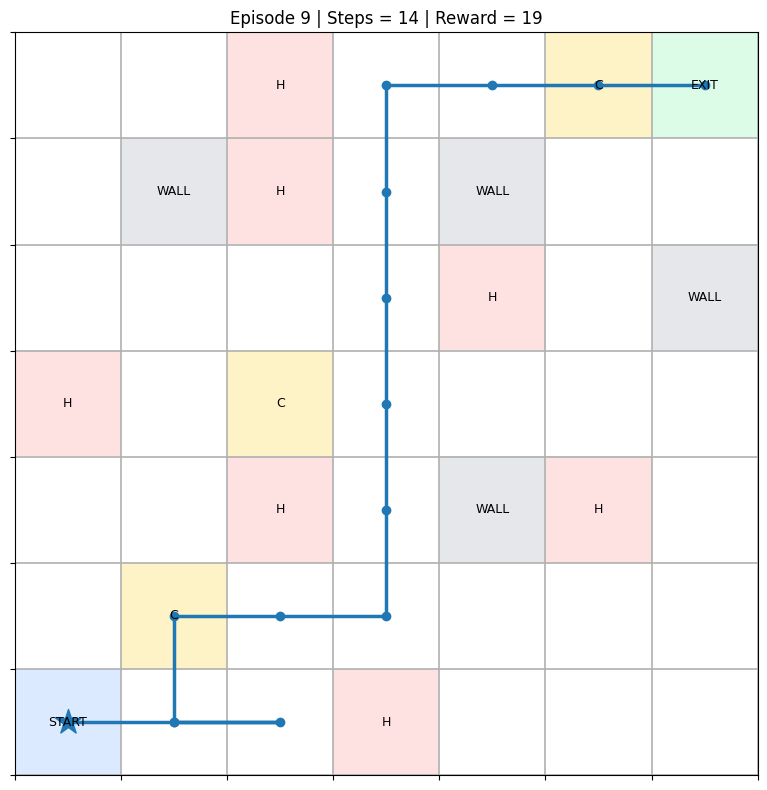


EPISODE 10 COMPLETED
Steps taken    : 71
Total reward   : -54
Reached EXIT   : True


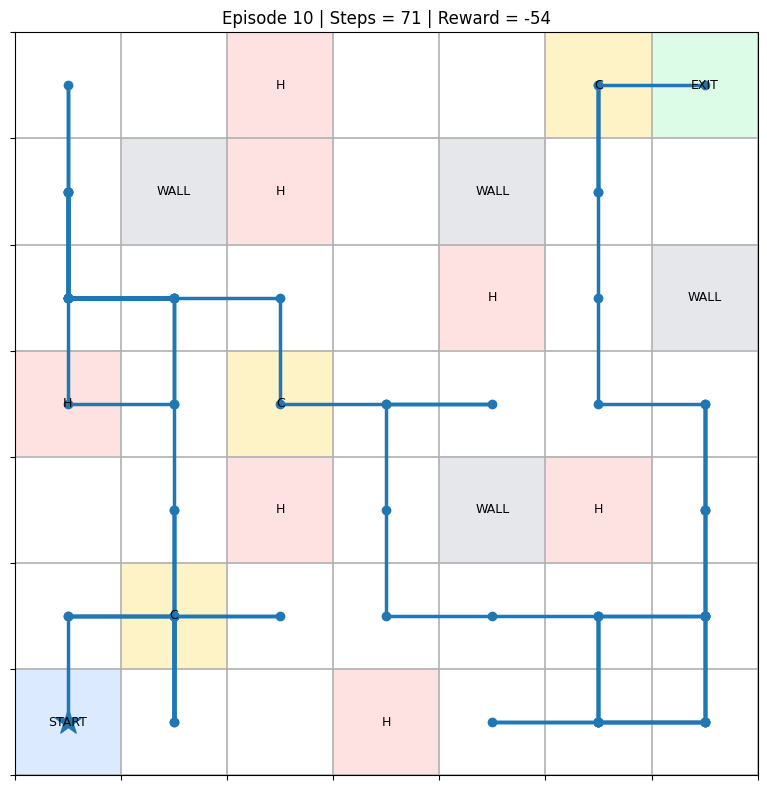


EPISODE 11 COMPLETED
Steps taken    : 50
Total reward   : -43
Reached EXIT   : True


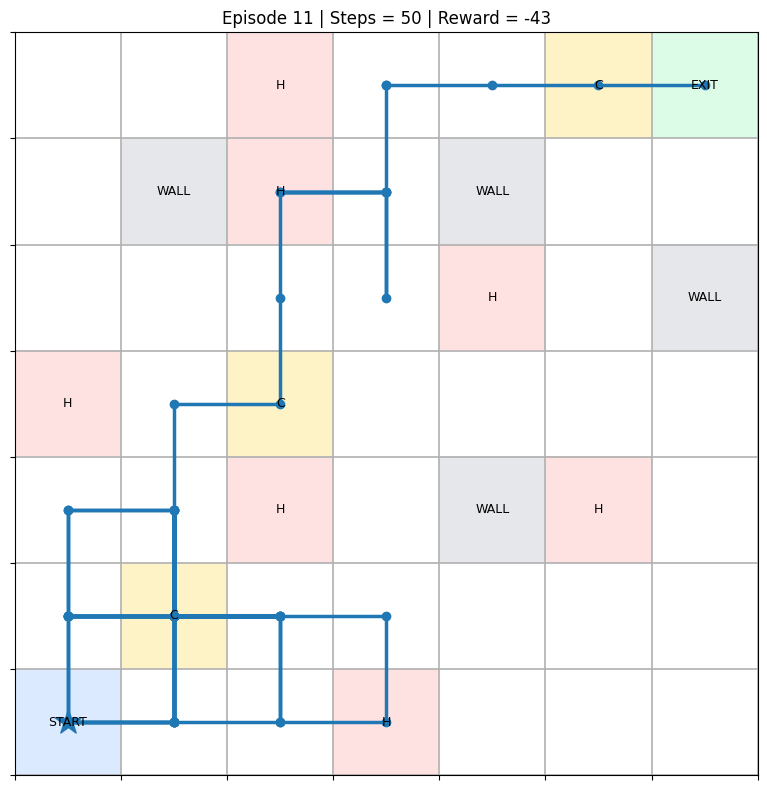


EPISODE 12 COMPLETED
Steps taken    : 31
Total reward   : -1
Reached EXIT   : True


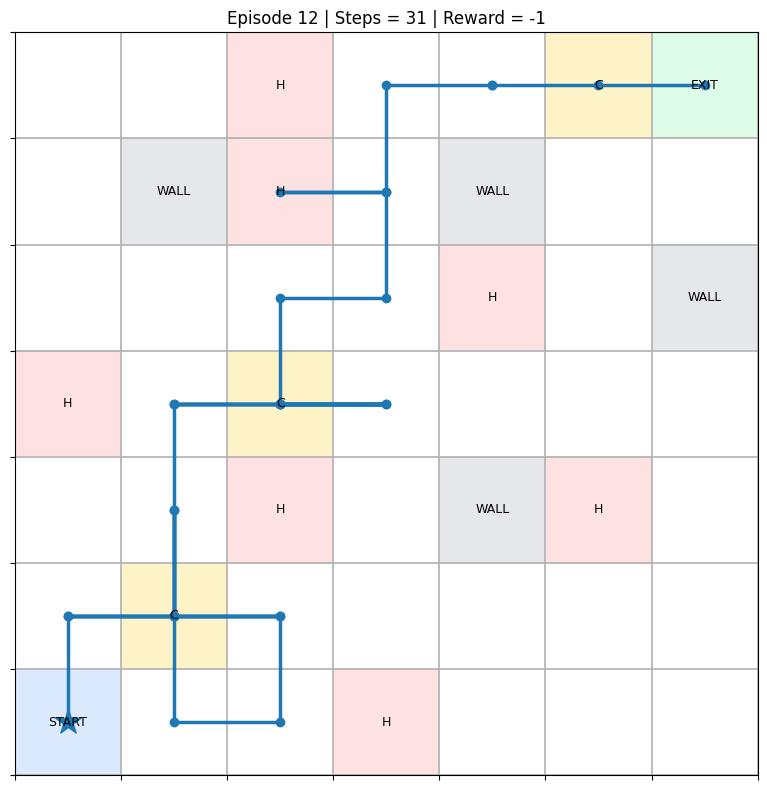


EPISODE 13 COMPLETED
Steps taken    : 33
Total reward   : -5
Reached EXIT   : True


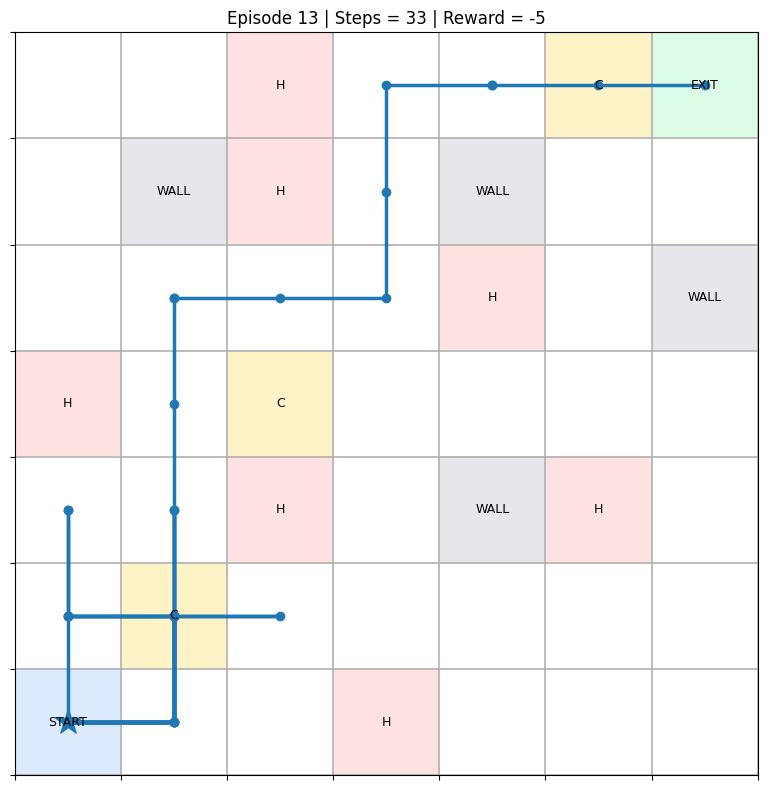


EPISODE 14 COMPLETED
Steps taken    : 12
Total reward   : 22
Reached EXIT   : True


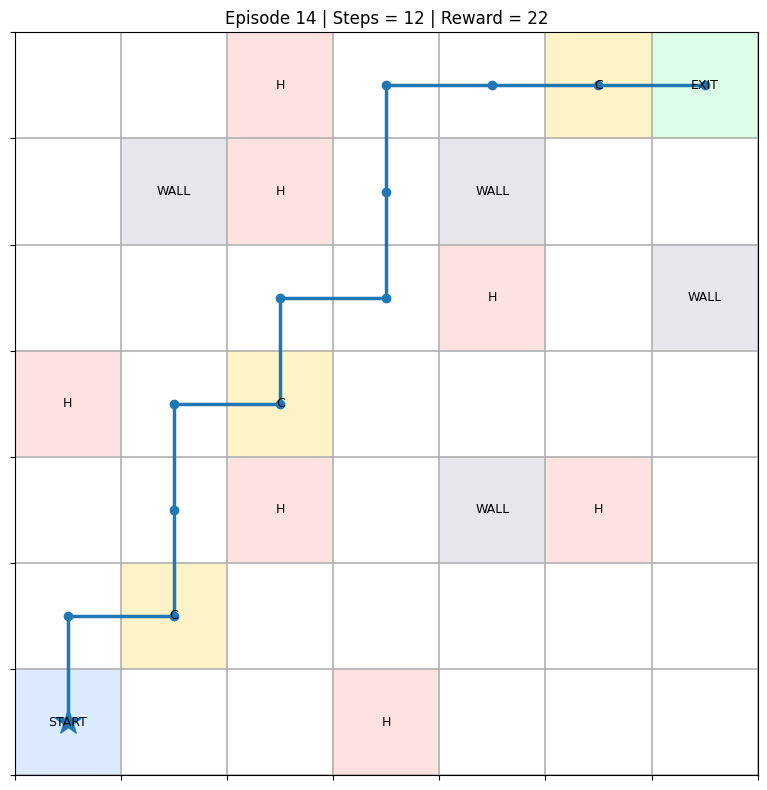


EPISODE 15 COMPLETED
Steps taken    : 38
Total reward   : 3
Reached EXIT   : True


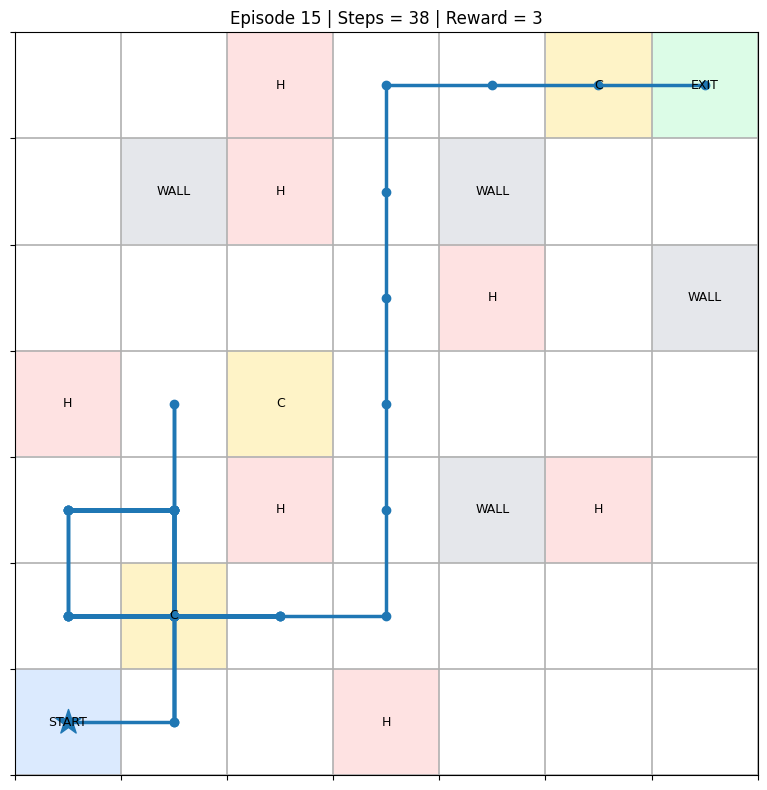


EPISODE 16 COMPLETED
Steps taken    : 19
Total reward   : 5
Reached EXIT   : True


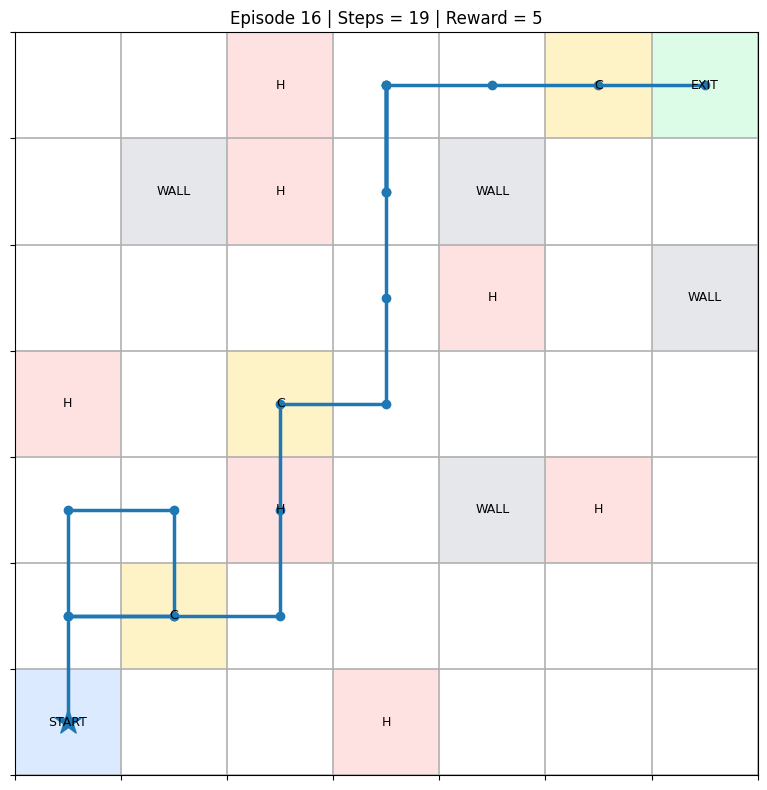


EPISODE 17 COMPLETED
Steps taken    : 23
Total reward   : 2
Reached EXIT   : True


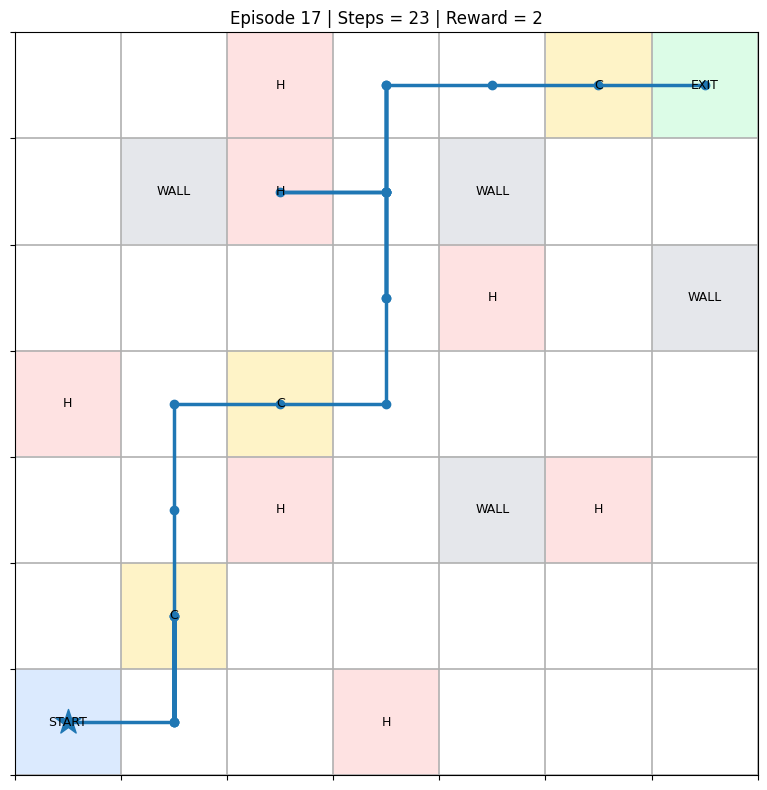


EPISODE 18 COMPLETED
Steps taken    : 23
Total reward   : -3
Reached EXIT   : True


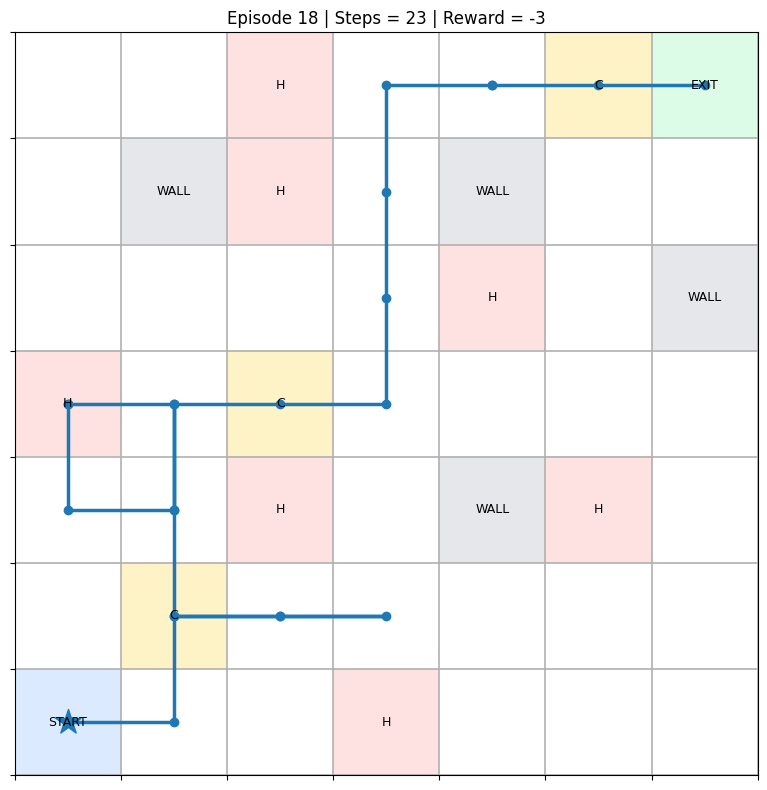


EPISODE 19 COMPLETED
Steps taken    : 24
Total reward   : 9
Reached EXIT   : True


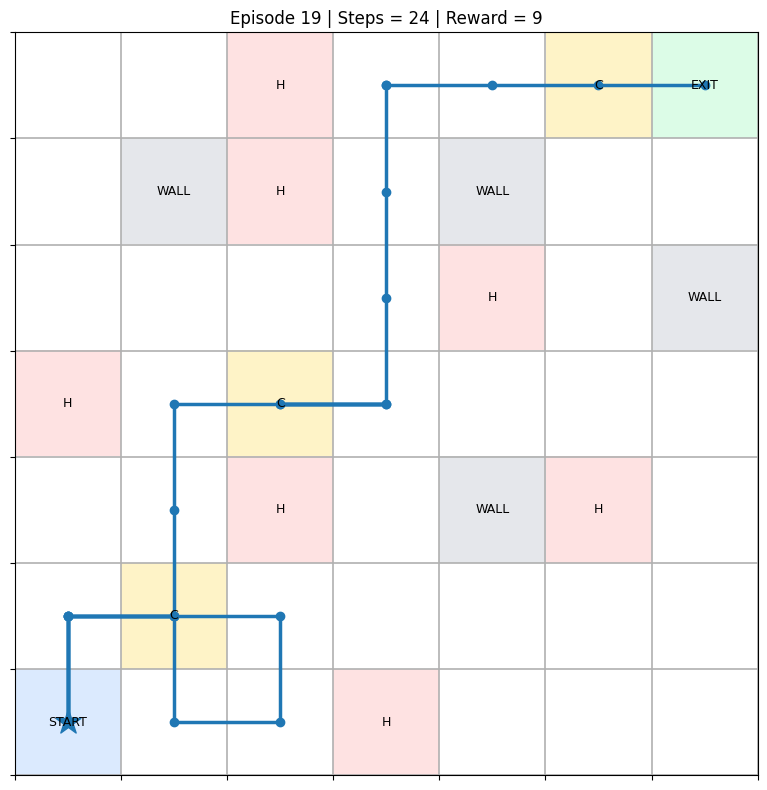


EPISODE 20 COMPLETED
Steps taken    : 14
Total reward   : 20
Reached EXIT   : True


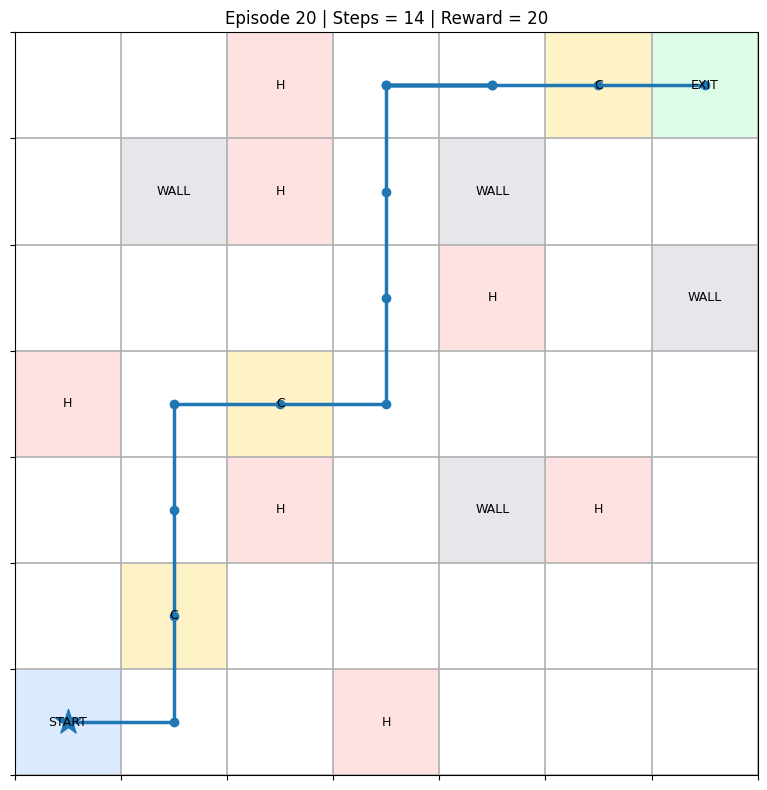


EPISODE 21 COMPLETED
Steps taken    : 18
Total reward   : 7
Reached EXIT   : True


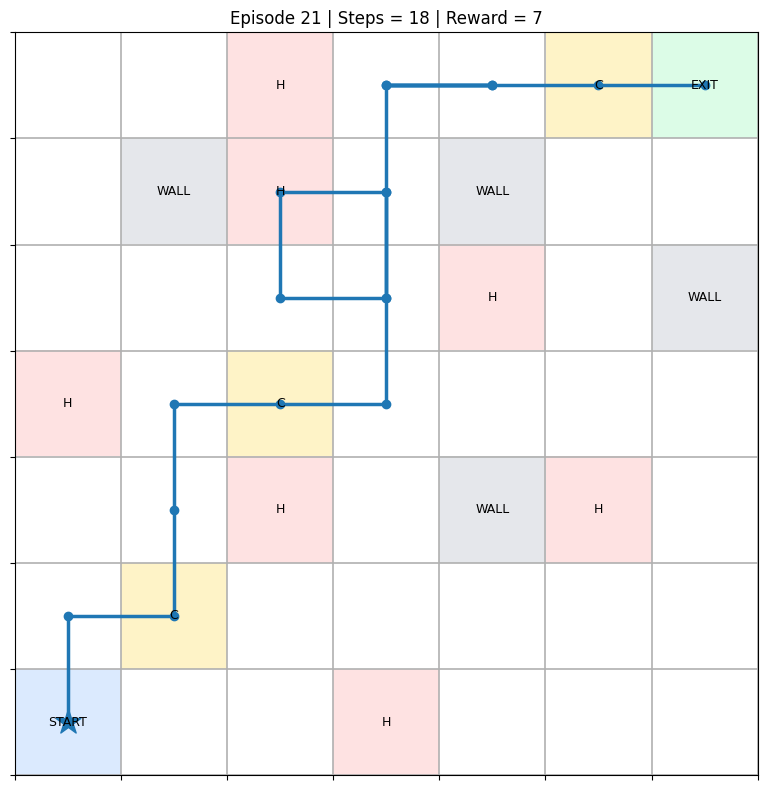


EPISODE 22 COMPLETED
Steps taken    : 16
Total reward   : 19
Reached EXIT   : True


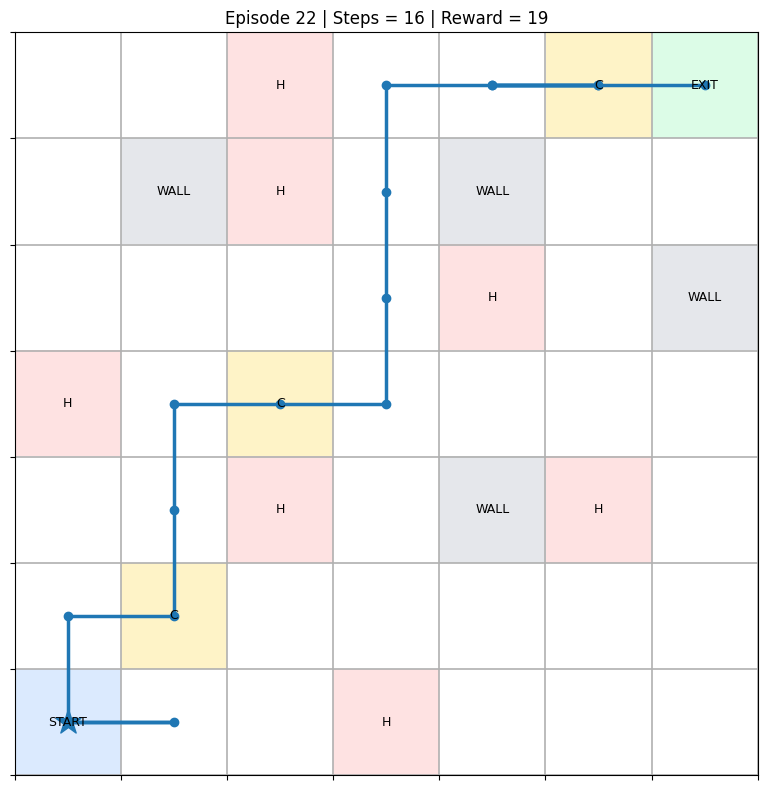


EPISODE 23 COMPLETED
Steps taken    : 18
Total reward   : 13
Reached EXIT   : True


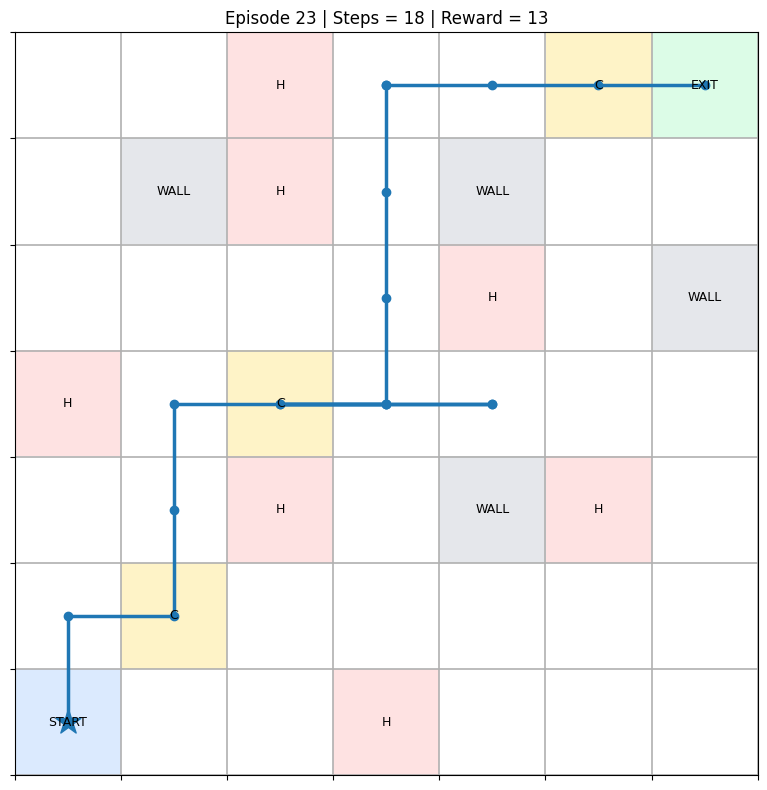


EPISODE 24 COMPLETED
Steps taken    : 22
Total reward   : 4
Reached EXIT   : True


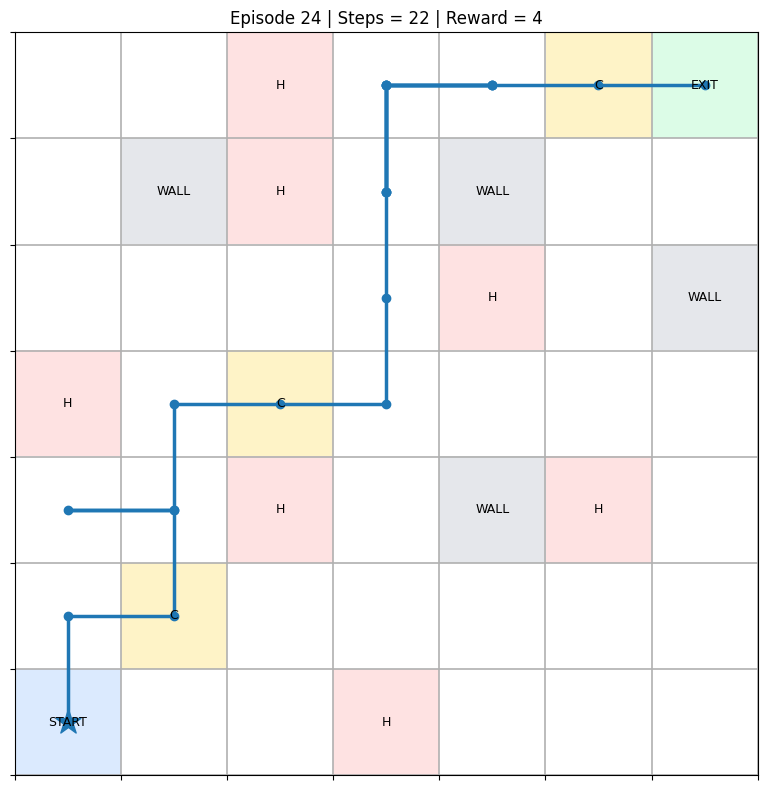


EPISODE 25 COMPLETED
Steps taken    : 14
Total reward   : 21
Reached EXIT   : True


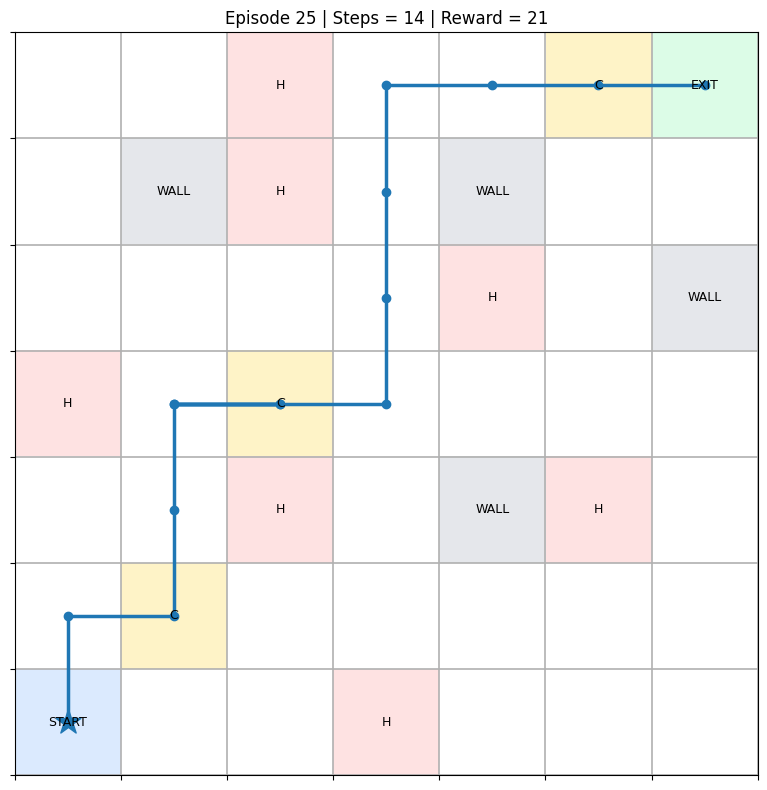


EPISODE 26 COMPLETED
Steps taken    : 14
Total reward   : 21
Reached EXIT   : True


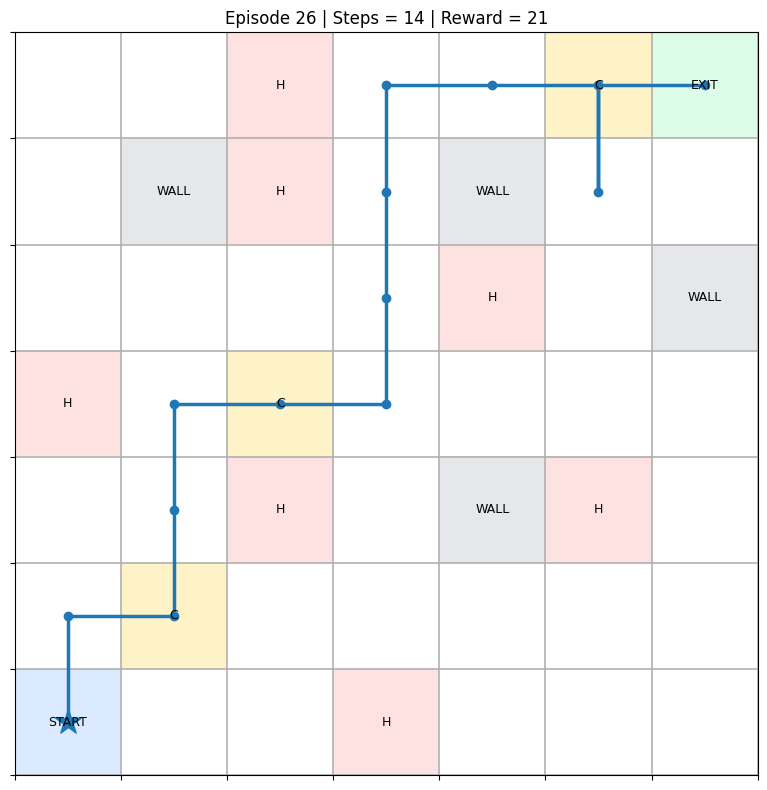


EPISODE 27 COMPLETED
Steps taken    : 12
Total reward   : 22
Reached EXIT   : True


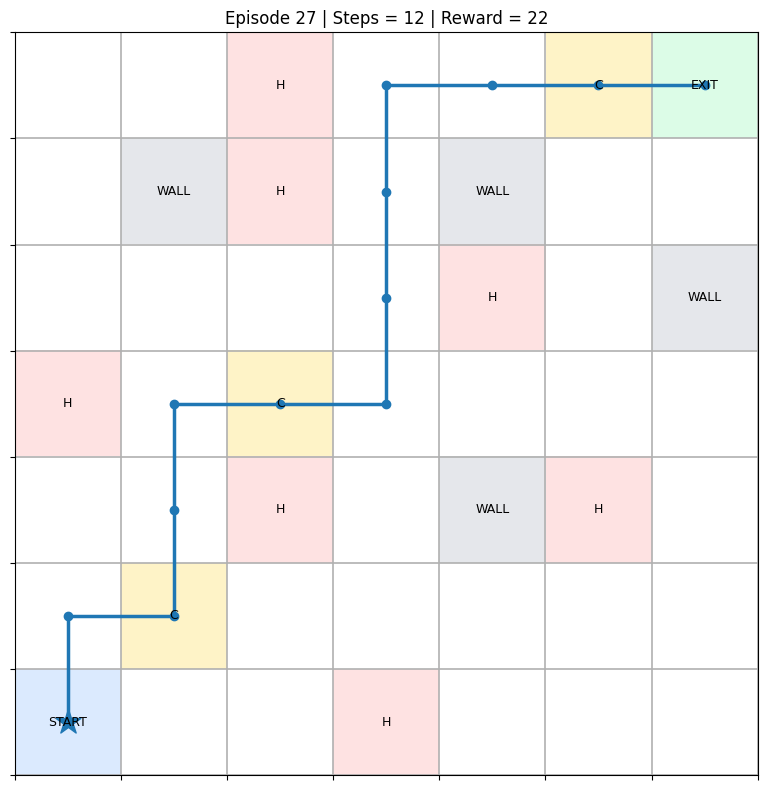


EPISODE 28 COMPLETED
Steps taken    : 14
Total reward   : 19
Reached EXIT   : True


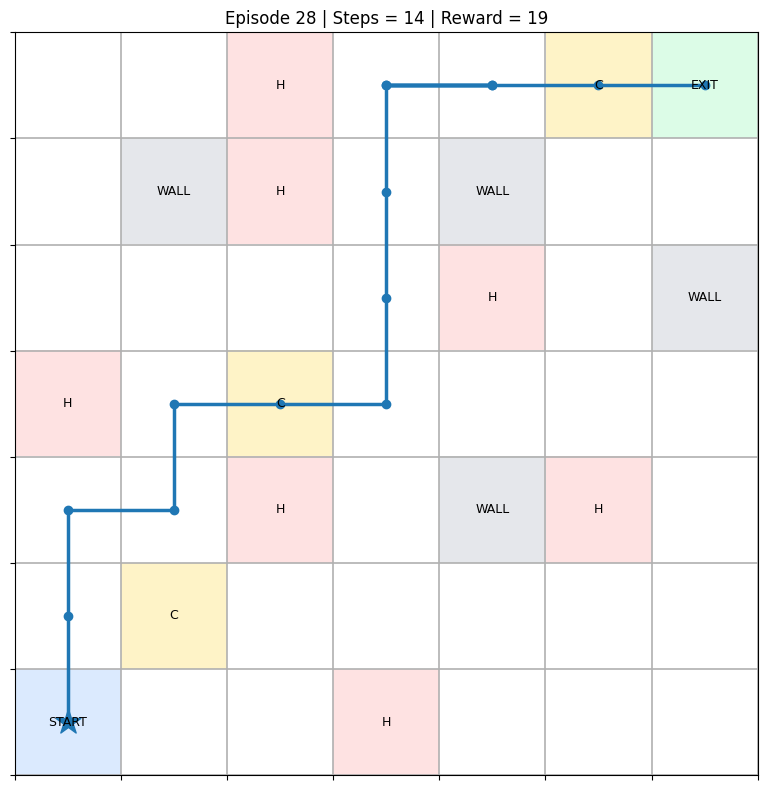


EPISODE 29 COMPLETED
Steps taken    : 22
Total reward   : 15
Reached EXIT   : True


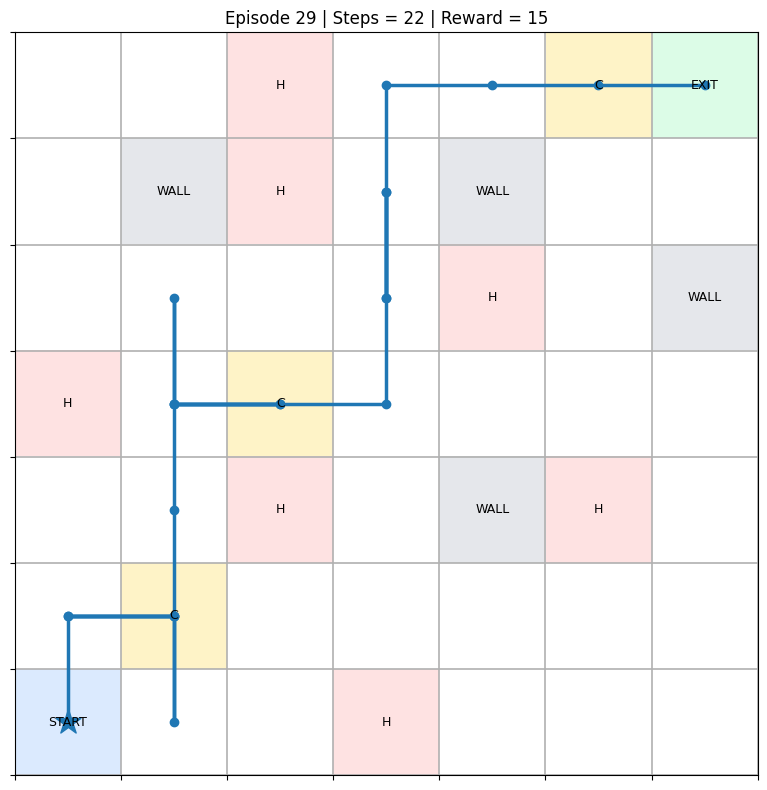


EPISODE 30 COMPLETED
Steps taken    : 13
Total reward   : 19
Reached EXIT   : True


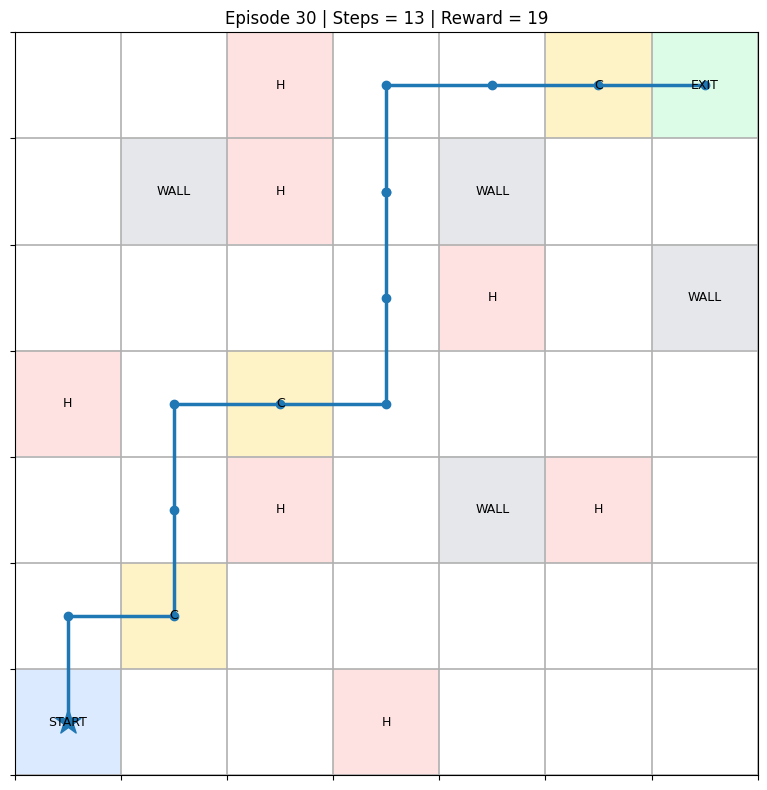


FINAL GREEDY PATH:
(6, 0) -> (5, 0) -> (5, 1) -> (4, 1) -> (3, 1) -> (3, 2) -> (3, 3) -> (2, 3) -> (1, 3) -> (0, 3) -> (0, 4) -> (0, 5) -> (0, 6)


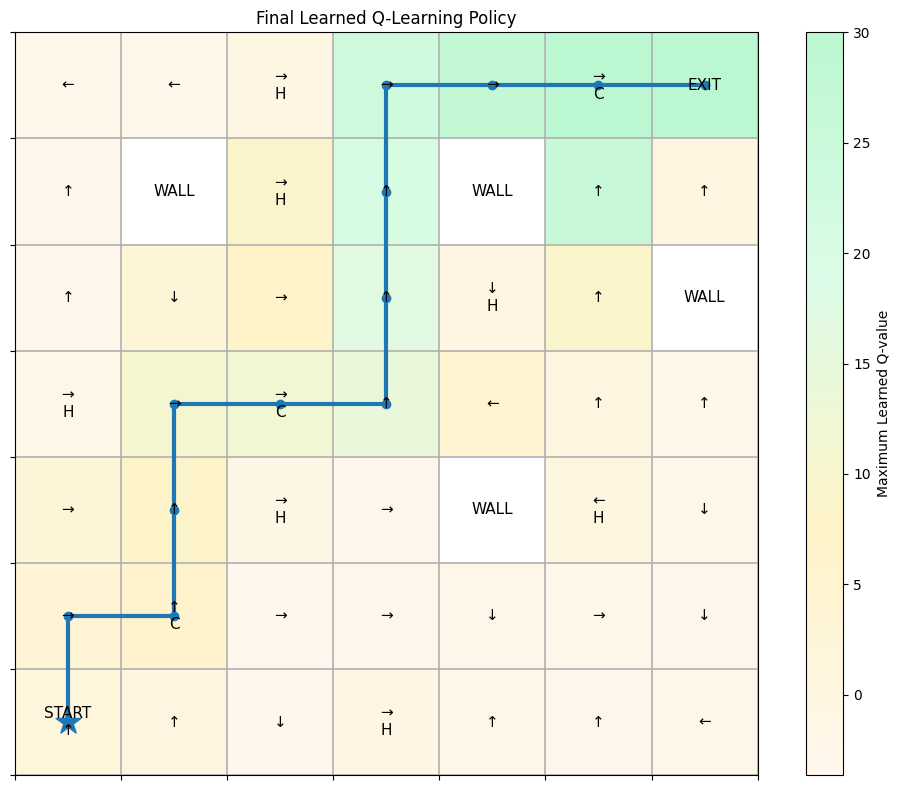

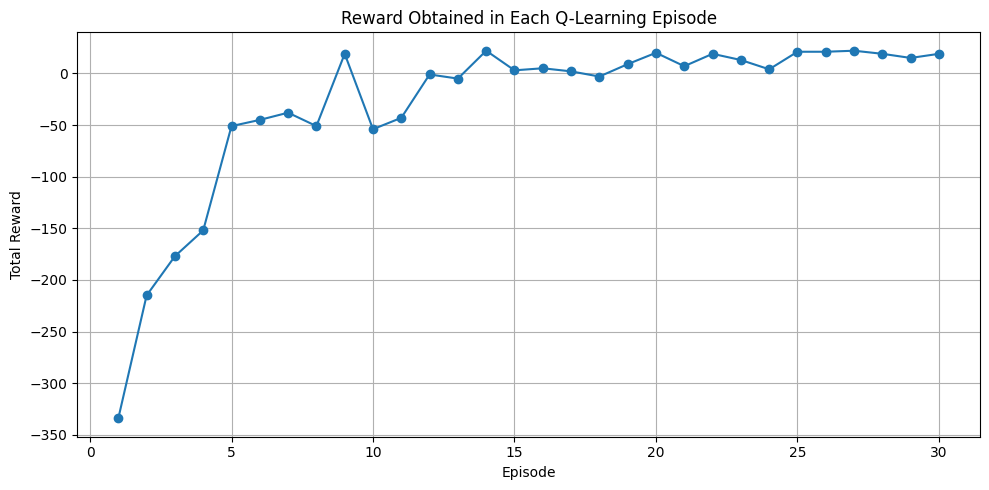

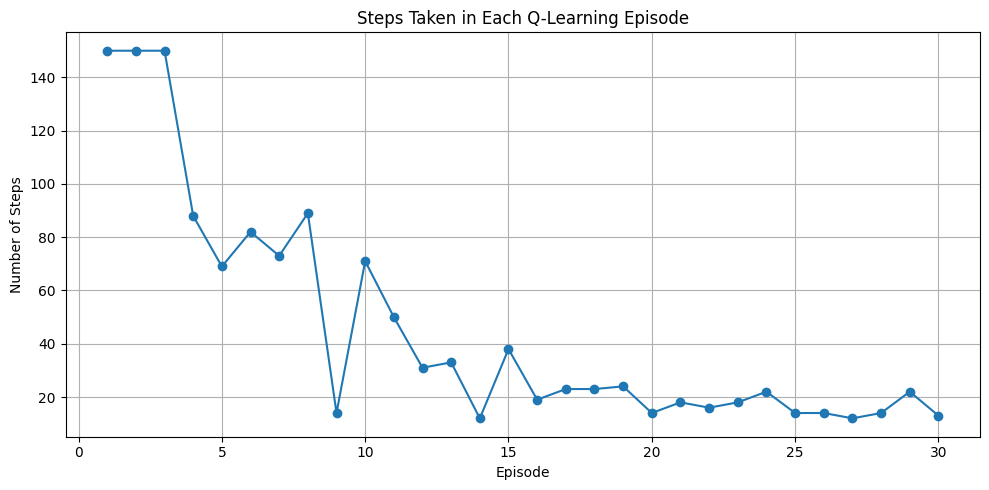

In [16]:
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap


# ============================================================
# 1. WAREHOUSE ENVIRONMENT
# ============================================================
#
# S = START
# E = EXIT / GOAL
# H = HAZARD
# C = SAFE / CHARGING CELL
# # = WALL
# . = NORMAL FLOOR
# ============================================================

warehouse = [
    [".", ".", "H", ".", ".", "C", "E"],
    [".", "#", "H", ".", "#", ".", "."],
    [".", ".", ".", ".", "H", ".", "#"],
    ["H", ".", "C", ".", ".", ".", "."],
    [".", ".", "H", ".", "#", "H", "."],
    [".", "C", ".", ".", ".", ".", "."],
    ["S", ".", ".", "H", ".", ".", "."]
]


number_of_rows = 7                 # Total number of warehouse rows
number_of_columns = 7              # Total number of warehouse columns

start_state = (6, 0)               # START position: bottom-left
goal_state = (0, 6)                # EXIT position: top-right


# ============================================================
# 2. POSSIBLE ACTIONS
# ============================================================

actions = {
    "UP": (-1, 0),                  # Move upward
    "DOWN": (1, 0),                 # Move downward
    "LEFT": (0, -1),                # Move left
    "RIGHT": (0, 1)                 # Move right
}


action_symbol = {
    "UP": "↑",
    "DOWN": "↓",
    "LEFT": "←",
    "RIGHT": "→"
}


# ============================================================
# 3. Q-LEARNING PARAMETERS
# ============================================================

learning_rate = 0.5                # alpha: amount of Q-value correction

discount_factor = 0.9              # gamma: importance of future rewards

exploration_rate = 0.2             # epsilon: 20% exploration

number_of_episodes = 30            # Classroom demo: show every episode

maximum_steps_per_episode = 150    # Prevent one episode from wandering forever


# Fixed random seed so classroom output is reproducible
random.seed(7)


# ============================================================
# 4. REWARDS
# ============================================================

normal_reward = -1                 # Cost of normal movement

hazard_reward = -10                # Penalty for entering hazard

safe_reward = 0                    # Reward for entering safe/charging cell

goal_reward = 30                   # Reward for reaching EXIT

wall_penalty = -3                  # Penalty for trying to hit wall/boundary


# ============================================================
# 5. IDENTIFY ALL VALID STATES
# ============================================================

valid_states = []
# Stores every position except walls


for row in range(number_of_rows):

    for column in range(number_of_columns):

        if warehouse[row][column] != "#":

            valid_states.append(
                (row, column)
            )


# ============================================================
# 6. INITIALIZE Q-TABLE
# ============================================================
#
# Q(S,a) = 0 for every state-action pair initially.
# The agent knows nothing at the beginning.
# ============================================================

q_table = {}


for state in valid_states:

    if state == goal_state:
        continue

    q_table[state] = {

        "UP": 0.0,                  # Initial Q(S, UP)
        "DOWN": 0.0,                # Initial Q(S, DOWN)
        "LEFT": 0.0,                # Initial Q(S, LEFT)
        "RIGHT": 0.0                # Initial Q(S, RIGHT)
    }


# ============================================================
# 7. STORAGE FOR LEARNING CURVES
# ============================================================

episode_rewards = []
# Total reward obtained in each episode


episode_steps = []
# Number of steps taken in each episode


# ============================================================
# 8. MOVE AGENT
# ============================================================

def move_agent(current_state, selected_action):

    current_row, current_column = current_state
    # Current robot location


    row_change, column_change = actions[
        selected_action
    ]
    # Movement corresponding to selected action


    next_row = current_row + row_change
    next_column = current_column + column_change


    # --------------------------------------------------------
    # CHECK GRID BOUNDARY
    # --------------------------------------------------------

    if (
        next_row < 0
        or next_row >= number_of_rows
        or next_column < 0
        or next_column >= number_of_columns
    ):

        return current_state, wall_penalty
        # Invalid move: stay at same state


    # --------------------------------------------------------
    # CHECK WALL
    # --------------------------------------------------------

    if warehouse[next_row][next_column] == "#":

        return current_state, wall_penalty
        # Wall hit: stay at same state


    next_state = (
        next_row,
        next_column
    )


    cell_type = warehouse[
        next_row
    ][
        next_column
    ]


    # --------------------------------------------------------
    # DETERMINE REWARD
    # --------------------------------------------------------

    if cell_type == "E":

        received_reward = goal_reward


    elif cell_type == "H":

        received_reward = hazard_reward


    elif cell_type == "C":

        received_reward = safe_reward


    else:

        received_reward = normal_reward


    return next_state, received_reward


# ============================================================
# 9. EPSILON-GREEDY ACTION SELECTION
# ============================================================

def choose_action(current_state):

    generated_random_number = random.random()
    # Random value between 0 and 1


    if generated_random_number < exploration_rate:

        selected_action = random.choice(
            list(actions.keys())
        )
        # Exploration: randomly select an action

        decision_type = "Exploration"


    else:

        current_action_values = q_table[
            current_state
        ]


        highest_q_value = max(
            current_action_values.values()
        )


        best_actions = [
            action
            for action, q_value
            in current_action_values.items()
            if q_value == highest_q_value
        ]
        # Several actions may initially tie at Q = 0


        selected_action = random.choice(
            best_actions
        )
        # Randomly break ties


        decision_type = "Exploitation"


    return (
        selected_action,
        decision_type,
        generated_random_number
    )


# ============================================================
# 10. COMMON LIGHT GRID COLORS
# ============================================================

light_colors = [

    "#ffffff",       # Normal floor
    "#dbeafe",       # START
    "#dcfce7",       # EXIT
    "#fee2e2",       # HAZARD
    "#fef3c7",       # SAFE
    "#e5e7eb"        # WALL
]


warehouse_cmap = ListedColormap(
    light_colors
)


cell_code = {

    ".": 0,
    "S": 1,
    "E": 2,
    "H": 3,
    "C": 4,
    "#": 5
}


# ============================================================
# 11. CREATE DISPLAY MATRIX
# ============================================================

def create_display_matrix():

    display_matrix = np.zeros(
        (
            number_of_rows,
            number_of_columns
        )
    )


    for row in range(number_of_rows):

        for column in range(number_of_columns):

            display_matrix[
                row,
                column
            ] = cell_code[
                warehouse[row][column]
            ]


    return display_matrix


# ============================================================
# 12. VISUALIZE INITIAL WAREHOUSE
# ============================================================

def visualize_initial_warehouse():

    display_matrix = create_display_matrix()


    plt.figure(
        figsize=(9, 8)
    )


    plt.imshow(
        display_matrix,
        cmap=warehouse_cmap,
        vmin=0,
        vmax=5
    )


    # --------------------------------------------------------
    # LABEL IMPORTANT CELLS
    # --------------------------------------------------------

    for row in range(number_of_rows):

        for column in range(number_of_columns):

            cell = warehouse[row][column]


            if cell == "S":

                text = "START"


            elif cell == "E":

                text = "EXIT"


            elif cell == "H":

                text = "HAZARD\n-10"


            elif cell == "C":

                text = "SAFE\n0"


            elif cell == "#":

                text = "WALL"


            else:

                text = ""


            plt.text(
                column,
                row,
                text,
                ha="center",
                va="center",
                fontsize=9
            )


    # Mark START
    plt.scatter(
        start_state[1],
        start_state[0],
        marker="*",
        s=350
    )


    # Draw cell boundaries
    plt.xticks(
        np.arange(-0.5, number_of_columns, 1),
        []
    )

    plt.yticks(
        np.arange(-0.5, number_of_rows, 1),
        []
    )

    plt.grid(
        True,
        linewidth=1.2
    )


    plt.title(
        "Warehouse Before Q-Learning"
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# 13. VISUALIZE ACTUAL TRAJECTORY OF AN EPISODE
# ============================================================

def visualize_episode_trajectory(
    episode_number,
    trajectory,
    total_episode_reward,
    number_of_steps
):

    display_matrix = create_display_matrix()


    plt.figure(
        figsize=(9, 8)
    )


    plt.imshow(
        display_matrix,
        cmap=warehouse_cmap,
        vmin=0,
        vmax=5
    )


    # --------------------------------------------------------
    # DRAW ACTUAL PATH TAKEN DURING THIS EPISODE
    # --------------------------------------------------------

    path_x = [
        state[1]
        for state in trajectory
    ]


    path_y = [
        state[0]
        for state in trajectory
    ]


    plt.plot(
        path_x,
        path_y,
        marker="o",
        linewidth=2.5
    )


    # Mark START
    plt.scatter(
        start_state[1],
        start_state[0],
        marker="*",
        s=350
    )


    # --------------------------------------------------------
    # CELL LABELS
    # --------------------------------------------------------

    for row in range(number_of_rows):

        for column in range(number_of_columns):

            cell = warehouse[row][column]


            if cell == "S":

                text = "START"


            elif cell == "E":

                text = "EXIT"


            elif cell == "H":

                text = "H"


            elif cell == "C":

                text = "C"


            elif cell == "#":

                text = "WALL"


            else:

                text = ""


            plt.text(
                column,
                row,
                text,
                ha="center",
                va="center",
                fontsize=9
            )


    plt.xticks(
        np.arange(-0.5, number_of_columns, 1),
        []
    )

    plt.yticks(
        np.arange(-0.5, number_of_rows, 1),
        []
    )

    plt.grid(
        True,
        linewidth=1.2
    )


    plt.title(
        f"Episode {episode_number} | "
        f"Steps = {number_of_steps} | "
        f"Reward = {total_episode_reward}"
    )


    plt.tight_layout()

    plt.show()


# ============================================================
# 14. SHOW INITIAL ENVIRONMENT
# ============================================================

print("\nINITIAL WAREHOUSE")

visualize_initial_warehouse()


# ============================================================
# 15. Q-LEARNING TRAINING
# ============================================================

for episode_number in range(
    1,
    number_of_episodes + 1
):


    current_state = start_state
    # Every episode begins at START


    total_episode_reward = 0
    # Total reward obtained during current episode


    trajectory = [
        current_state
    ]
    # Actual path followed in current episode


    reached_goal = False
    # Becomes True if agent reaches EXIT


    # --------------------------------------------------------
    # BEGIN ONE EPISODE
    # --------------------------------------------------------

    for step_number in range(
        1,
        maximum_steps_per_episode + 1
    ):


        # ====================================================
        # SELECT ACTION
        # ====================================================

        (
            selected_action,
            decision_type,
            generated_random_number
        ) = choose_action(
            current_state
        )


        # ====================================================
        # INTERACT WITH ENVIRONMENT
        # ====================================================

        next_state, received_reward = move_agent(
            current_state,
            selected_action
        )


        total_episode_reward += (
            received_reward
        )


        trajectory.append(
            next_state
        )


        # ====================================================
        # CURRENT Q-VALUE
        # ====================================================

        current_q_value = q_table[
            current_state
        ][
            selected_action
        ]


        # ====================================================
        # BEST FUTURE Q-VALUE
        # ====================================================

        if next_state == goal_state:

            best_future_q_value = 0.0
            # Goal is terminal


        else:

            best_future_q_value = max(
                q_table[next_state].values()
            )


        # ====================================================
        # Q-LEARNING TARGET
        # ====================================================

        target_q_value = (
            received_reward
            + discount_factor
            * best_future_q_value
        )


        # ====================================================
        # Q-VALUE ERROR
        # ====================================================

        q_value_error = (
            target_q_value
            - current_q_value
        )


        # ====================================================
        # UPDATED Q-VALUE
        # ====================================================

        updated_q_value = (
            current_q_value
            + learning_rate
            * q_value_error
        )


        # ====================================================
        # FULL DETAILS FOR FIRST THREE EPISODES
        # ====================================================

        if episode_number <= 3:

            print(
                "\n" + "=" * 72
            )

            print(
                f"Episode {episode_number} | Step {step_number}"
            )

            print(
                "=" * 72
            )

            print(
                f"Current State          : {current_state}"
            )

            print(
                f"Random Number          : {generated_random_number:.3f}"
            )

            print(
                f"Decision               : {decision_type}"
            )

            print(
                f"Selected Action        : {selected_action}"
            )

            print(
                f"Next State             : {next_state}"
            )

            print(
                f"Reward                 : {received_reward}"
            )

            print(
                f"Current Q-value        : {current_q_value:.3f}"
            )

            print(
                f"Best Future Q-value    : {best_future_q_value:.3f}"
            )

            print(
                f"Target Q-value         : {target_q_value:.3f}"
            )


            print("\nQ-learning Equation:")

            print(
                "Q_new(S,a) = Q_old(S,a) "
                "+ alpha * [r + gamma * max Q(S',a') - Q_old(S,a)]"
            )


            print("\nNumerical Substitution:")

            print(
                f"Q_new({current_state},{selected_action}) "
                f"= {current_q_value:.3f} "
                f"+ {learning_rate:.3f} * "
                f"[{received_reward:.3f} "
                f"+ {discount_factor:.3f} * {best_future_q_value:.3f} "
                f"- {current_q_value:.3f}]"
            )


            print("\nSimplified:")

            print(
                f"Q_new({current_state},{selected_action}) "
                f"= {current_q_value:.3f} "
                f"+ {learning_rate:.3f} "
                f"* ({q_value_error:.3f})"
            )


            print(
                f"Q_new({current_state},{selected_action}) "
                f"= {updated_q_value:.3f}"
            )


        # ====================================================
        # STORE UPDATED Q-VALUE
        # ====================================================

        q_table[
            current_state
        ][
            selected_action
        ] = updated_q_value


        # ====================================================
        # MOVE TO NEXT STATE
        # ====================================================

        current_state = next_state


        # ====================================================
        # CHECK WHETHER EXIT WAS REACHED
        # ====================================================

        if current_state == goal_state:

            reached_goal = True

            break


    # ========================================================
    # STORE EPISODE RESULTS
    # ========================================================

    episode_rewards.append(
        total_episode_reward
    )


    episode_steps.append(
        step_number
    )


    # ========================================================
    # PRINT EPISODE SUMMARY
    # ========================================================

    print(
        "\n" + "=" * 72
    )

    print(
        f"EPISODE {episode_number} COMPLETED"
    )

    print(
        "=" * 72
    )

    print(
        f"Steps taken    : {step_number}"
    )

    print(
        f"Total reward   : {total_episode_reward}"
    )

    print(
        f"Reached EXIT   : {reached_goal}"
    )


    # ========================================================
    # DISPLAY GRID AFTER EVERY EPISODE
    # ========================================================

    visualize_episode_trajectory(
        episode_number,
        trajectory,
        total_episode_reward,
        step_number
    )


# ============================================================
# 16. EXTRACT FINAL GREEDY POLICY
# ============================================================

learned_policy = {}


for state in q_table:

    learned_policy[state] = max(
        q_table[state],
        key=q_table[state].get
    )
    # Choose action with largest learned Q-value


# ============================================================
# 17. FIND FINAL GREEDY PATH
# ============================================================

def get_final_greedy_path():

    current_state = start_state

    greedy_path = [
        current_state
    ]


    maximum_path_steps = 100


    for _ in range(
        maximum_path_steps
    ):


        if current_state == goal_state:

            break


        selected_action = learned_policy[
            current_state
        ]


        next_state, _ = move_agent(
            current_state,
            selected_action
        )


        # Stop if final policy creates a loop
        if (
            next_state in greedy_path
            and next_state != goal_state
        ):

            break


        greedy_path.append(
            next_state
        )


        current_state = next_state


    return greedy_path


final_greedy_path = get_final_greedy_path()


print(
    "\nFINAL GREEDY PATH:"
)

print(
    " -> ".join(
        str(state)
        for state in final_greedy_path
    )
)


# ============================================================
# 18. VISUALIZE FINAL LEARNED POLICY
# ============================================================

def visualize_learned_policy():

    maximum_q_matrix = np.full(
        (
            number_of_rows,
            number_of_columns
        ),
        np.nan
    )


    for state in q_table:

        row, column = state

        maximum_q_matrix[
            row,
            column
        ] = max(
            q_table[state].values()
        )


    maximum_q_matrix[
        goal_state
    ] = goal_reward


    light_value_cmap = LinearSegmentedColormap.from_list(
        "light_values",
        [
            "#fff7ed",
            "#fef3c7",
            "#dcfce7",
            "#bbf7d0"
        ]
    )


    plt.figure(
        figsize=(10, 8)
    )


    plt.imshow(
        maximum_q_matrix,
        cmap=light_value_cmap
    )


    plt.colorbar(
        label="Maximum Learned Q-value"
    )


    # --------------------------------------------------------
    # DRAW POLICY ARROWS
    # --------------------------------------------------------

    for row in range(number_of_rows):

        for column in range(number_of_columns):

            cell = warehouse[row][column]

            state = (
                row,
                column
            )


            if cell == "#":

                text = "WALL"


            elif cell == "E":

                text = "EXIT"


            elif state in learned_policy:

                best_action = learned_policy[
                    state
                ]


                arrow = action_symbol[
                    best_action
                ]


                if cell == "S":

                    text = (
                        "START\n"
                        + arrow
                    )


                elif cell == "H":

                    text = (
                        arrow
                        + "\nH"
                    )


                elif cell == "C":

                    text = (
                        arrow
                        + "\nC"
                    )


                else:

                    text = arrow


            else:

                text = ""


            plt.text(
                column,
                row,
                text,
                ha="center",
                va="center",
                fontsize=11
            )


    # --------------------------------------------------------
    # DRAW FINAL GREEDY PATH
    # --------------------------------------------------------

    path_x = [
        state[1]
        for state in final_greedy_path
    ]


    path_y = [
        state[0]
        for state in final_greedy_path
    ]


    if len(path_x) > 1:

        plt.plot(
            path_x,
            path_y,
            marker="o",
            linewidth=3
        )


    plt.scatter(
        start_state[1],
        start_state[0],
        marker="*",
        s=350
    )


    plt.xticks(
        np.arange(-0.5, number_of_columns, 1),
        []
    )

    plt.yticks(
        np.arange(-0.5, number_of_rows, 1),
        []
    )

    plt.grid(
        True,
        linewidth=1.2
    )


    plt.title(
        "Final Learned Q-Learning Policy"
    )

    plt.tight_layout()

    plt.show()


visualize_learned_policy()


# ============================================================
# 19. REWARD CURVE
# ============================================================

plt.figure(
    figsize=(10, 5)
)


plt.plot(
    range(1, number_of_episodes + 1),
    episode_rewards,
    marker="o"
)


plt.xlabel(
    "Episode"
)

plt.ylabel(
    "Total Reward"
)

plt.title(
    "Reward Obtained in Each Q-Learning Episode"
)

plt.grid(
    True
)

plt.tight_layout()

plt.show()


# ============================================================
# 20. STEPS-PER-EPISODE CURVE
# ============================================================

plt.figure(
    figsize=(10, 5)
)


plt.plot(
    range(1, number_of_episodes + 1),
    episode_steps,
    marker="o"
)


plt.xlabel(
    "Episode"
)

plt.ylabel(
    "Number of Steps"
)

plt.title(
    "Steps Taken in Each Q-Learning Episode"
)

plt.grid(
    True
)

plt.tight_layout()

plt.show()